# Moving application of ShellSIM from 1D time series data to complex 4D gridded dataset

Needed Variables 

T_timeseries=  Temperature Time series  
S_timeseries=  Practical Salinity Time series  
Chl_timeseries= Chlorophyll Time series  
POC_timeseries= Particulate Organic Carbon Time series  
POM_timeseries=  Particulate Organic Matter Time series  
TPM_timeseries= Total Particulate Matter   Time series  

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
from dask.diagnostics import ProgressBar
import warnings
import gc
import datetime
from contextlib import redirect_stdout
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import netCDF4
import matplotlib as mpl
from PIL import Image
import folium
import io
import base64
from branca.colormap import linear



In [2]:
# ============================================================
# TIME HORIZON DEFINITION
# ============================================================
# Defines the simulation period as a daily DatetimeIndex.
# time_horizon_len is the number of forward-Euler steps the
# model wrapper will execute per pixel. This is also the length
# of every time-series array passed into run_fabm_at_point_full.
#
# ⚠️  Always use ISO-8601 format (YYYY-MM-DD) for pd.date_range
#    to avoid ambiguous MM-DD vs DD-MM parsing by pandas.

# Define the integration time period
start = '2021-01-01'   # Jan 1, 2021
end   = '2021-12-31'   # December 31, 2021
time_horizon     = pd.date_range(start=start, end=end, freq='1d')
time_horizon_len = len(time_horizon)
print(f"Simulation period: {time_horizon[0].date()} → {time_horizon[-1].date()}  ({time_horizon_len} days)")
time_horizon_len

Simulation period: 2021-01-01 → 2021-12-31  (365 days)


365

In [3]:
# ============================================================
# CHUNKING CONFIG AND load_nc_file HELPER FUNCTION
# ============================================================
# chunking_config partitions the 3-D (time, lat, lon) arrays
# into Dask tiles. time=-1 means the ENTIRE time axis stays in
# one chunk — required because ShellSIM is a sequential time-
# stepping model and cannot be split along the time axis.
#
# Chunk-size tuning note:
#   lat=80, lon=110 are good starting values. Each chunk is
#   approximately 80 * 110 * 365 * 8 bytes ~ 236 MB per
#   variable. If you have limited RAM, reduce to lat=40,
#   lon=55 (~ 59 MB per variable).
#   Rule of thumb: keep each chunk at or below ~100 MB.
#
# load_nc_file: attempts to open a real netCDF file; if the
# file is missing it generates synthetic random data on the
# same grid as the first real dataset. This fallback lets the
# notebook run end-to-end on machines that only have partial
# data (useful for development and testing).

#  Lat lon chunking method
chunking_config={'time': -1, 'latitude': 80, 'longitude': 110}
# Earth's radius in kilometers (used for converting degrees to distance)
# The mean radius is a good approximation for surface area calculation.
EARTH_RADIUS_KM = 6371.0 # km
_GLOBAL_COORDS = None


def load_nc_file(file_path, var_name_in_file, chunking_config=None):
    """
    Loads a NetCDF file or creates a fake one if not found.
    """
    global _GLOBAL_COORDS
    fake_filename = f'{var_name_in_file}_gridded_FAKE.nc'
    
    if os.path.exists(file_path):
        print(f"Successfully loaded: {var_name_in_file}")
        # Load the dataset
        ds = xr.open_dataset(file_path, chunks=chunking_config)
        # --- START COORDINATE & AREA CALCULATION BLOCK ---
        try:
            # 1. Get Lat/Lon coordinates safely
            lat_coords = ds['latitude'].values if 'latitude' in ds.coords else ds['lat'].values
            lon_coords = ds['longitude'].values if 'longitude' in ds.coords else ds['lon'].values
    
            # Get time coordinate if it exists
            time_coords = ds['time'].values if 'time' in ds.coords else None
            
            # Store global coordinates from the FIRST real dataset loaded
            if _GLOBAL_COORDS is None:
                _GLOBAL_COORDS = {
                    'lat': lat_coords,
                    'lon': lon_coords,
                    'time': time_coords,  
                    'lat_name': 'latitude' if 'latitude' in ds.coords else 'lat',
                    'lon_name': 'longitude' if 'longitude' in ds.coords else 'lon'
                }
                print(f"✅ Set global coordinate reference from: {var_name_in_file}")
            
        except KeyError:
            print("❌ ERROR: The dataset is missing coordinate variables. Expected ('latitude' or 'lat') and ('longitude' or 'lon').")
            return ds

        # Calculate bounds and ranges
        lat_min, lat_max = lat_coords.min(), lat_coords.max()
        lon_min, lon_max = lon_coords.min(), lon_coords.max()

        lat_range_deg = lat_max - lat_min
        lon_range_deg = lon_max - lon_min
        
        # 2. Convert ranges to distance
        lat_distance_km = lat_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360)
        
        mid_lat_rad = np.deg2rad((lat_max + lat_min) / 2)
        lon_distance_km = lon_range_deg * (2 * np.pi * EARTH_RADIUS_KM / 360) * np.cos(mid_lat_rad)
        
        # 3. Calculate Approximate Area
        approx_area_sq_km = lat_distance_km * lon_distance_km
        
        print(f"🗺️ Geographic Coverage:")
        print(f"  BBOX (xMin, yMin, xMax, yMax)")
        print(f"  BBOX ({lon_min:.2f}, {lat_min:.2f}, {lon_max:.2f}, {lat_max:.2f})")
        print(f"  Lat Range: {lat_min:.2f}° to {lat_max:.2f}° ({lat_range_deg:.2f}°)")
        print(f"  Lon Range: {lon_min:.2f}° to {lon_max:.2f}° ({lon_range_deg:.2f}°)")
        print(f"  Approximate Area: {approx_area_sq_km:,.0f} km²")
        print("---------------------------------------------------\n")
        
        return ds
    
    if os.path.exists(fake_filename):
        print(f"Using existing fake dataset: {fake_filename}\n")
        return xr.open_dataset(fake_filename, chunks=chunking_config)

    # Check if we have global coordinates from a real dataset
    if _GLOBAL_COORDS is None:
        print("⚠️ WARNING: No real dataset loaded yet. Creating fake data with default coordinates.")
        fake_lats = np.linspace(40, 50, 100)
        fake_lons = np.linspace(-10, 0, 100)
        lat_name = 'latitude'
        lon_name = 'longitude'
    else:
        print(f"📍 Creating fake data matching global coordinate reference")
        fake_lats = _GLOBAL_COORDS['lat']
        fake_lons = _GLOBAL_COORDS['lon']
        lat_name  = _GLOBAL_COORDS['lat_name']
        lon_name  = _GLOBAL_COORDS['lon_name']

    # ── FIX: use the module-level simulation `time_horizon` for fake data
    #    timestamps — NOT _GLOBAL_COORDS['time'] (the real CMEMS dataset's
    #    time, which only covers a few weeks, e.g. June 2021).
    #
    #    Using the short CMEMS time means all 4-5 June data points get
    #    extrapolated to the full year at the interp step.  That produces
    #    near-zero or negative food concentrations for months far from June,
    #    which are then clamped to 0 → oyster starvation → NaN after ~90 days.
    #
    #    With `time_horizon` (the full simulation year) as the fake-data time
    #    axis, the interp step becomes a no-op (same axis) and the fake values
    #    stay in their generated range for all 365 days.
    #
    #    IMPORTANT: Do NOT assign to a local variable named `time_horizon` here
    #    — we intentionally read the module-level simulation variable.
    fake_n_times = len(time_horizon)  # module-level simulation time_horizon

    # Generate fake values in a biologically plausible range.
    # np.random.rand() alone gives [0,1) which is severely food-limited for
    # an oyster model (half-saturation constants are typically 1–10 mg/m³).
    # Using [1, 11] keeps temperature in a cold-but-valid range and gives
    # the model enough food to run the full simulation year.
    fake_data = np.random.rand(fake_n_times, len(fake_lats), len(fake_lons)) * 10 + 1

    fake_gridded_dataset = xr.Dataset(
        {var_name_in_file: (['time', lat_name, lon_name], fake_data)},
        coords={'time': time_horizon, lat_name: fake_lats, lon_name: fake_lons}
    )

    fake_gridded_dataset.to_netcdf(fake_filename)
    print(f"✅ Saved fake dataset to: {fake_filename}")
    print(f"   Coordinates: time[{fake_n_times}], {lat_name}[{len(fake_lats)}], {lon_name}[{len(fake_lons)}]")
    print(f"   BBOX ({fake_lons.min():.2f}, {fake_lats.min():.2f}, {fake_lons.max():.2f}, {fake_lats.max():.2f})\n")

    return xr.open_dataset(fake_filename, chunks=chunking_config)

    

In [4]:
# ============================================================
# INPUT FILE PATHS AND VARIABLE NAMES
# ============================================================
# Each environmental forcing variable lives in its own netCDF
# downloaded from CMEMS. Setting a path to a non-existent file
# triggers the fake-data fallback in load_nc_file so the full
# pipeline can be tested without all data present.
# To use real data: replace the path strings with valid paths.

# Define datasets to be read and used for model
poc_file_path="/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc"
poc_var_name = 'poc'  # variable name inside poc.nc

salinity_file_path="/home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc"
salinity_var_name = 'sos' # variable name inside salinity.nc

# Fake data generation to be triggered in the 'except' block of load_nc_file if path doesn't exist
temp_file_path = 'non_existent_temp.nc'
temp_var_name = 'temperature' # variable name inside temperature.nc

chl_file_path = 'non_existent_chl.nc'
chl_var_name = 'chl'

pom_file_path = 'non_existent_pom.nc'
pom_var_name = 'pom'

tpm_file_path = 'non_existent_tpm.nc'
tpm_var_name = 'tpm'


In [5]:
# ============================================================
# LOAD ALL SIX FORCING DATASETS
# ============================================================
# Calls load_nc_file for each variable. The first successfully
# loaded real dataset sets _GLOBAL_COORDS (the master grid);
# all subsequent fake datasets are generated on that same
# lat/lon/time grid so all arrays are automatically aligned.
# After this cell we have six lazy Dask-backed DataArrays;
# no large data has been read into RAM yet.

# Load all datasets
print("Loading datasets...\n")
# view bbox with http://bboxfinder.com/#30.060000,-12.940000,69.940000,41.940000
ds_poc = load_nc_file(poc_file_path, poc_var_name)
ds_sal = load_nc_file(salinity_file_path, salinity_var_name)
ds_temp = load_nc_file(temp_file_path, temp_var_name)
ds_chl = load_nc_file(chl_file_path, chl_var_name)
ds_pom = load_nc_file(pom_file_path, pom_var_name)
ds_tpm = load_nc_file(tpm_file_path, tpm_var_name)

Loading datasets...

Successfully loaded: poc


getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_BIO_BGC_3D_REP_015_010/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_poc_13.00W-42.00E_30.00N-70.00N_0.00-1000.00m_2021-06-01-2021-06-30_3f1f32d8adbe3d686e11d7d4a40be7bb.nc: Operation not supported


✅ Set global coordinate reference from: poc
🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (-12.88, 30.12, 41.88, 69.88)
  Lat Range: 30.12° to 69.88° (39.75°)
  Lon Range: -12.88° to 41.88° (54.75°)
  Approximate Area: 17,296,519 km²
---------------------------------------------------

Successfully loaded: sos


getfattr: /home/jovyan/wise_data_store/hda_download/MULTIOBS_GLO_PHY_S_SURFACE_MYNRT_015_013/cmems_obs-mob_glo_phy-sss_my_multi_P1D_sos-sos_error_13.00W-42.00E_30.00N-70.00N_2021-06-01-2021-06-30_9fe69177ea51eb9c1d733df494870646.nc: Operation not supported


🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (-12.94, 30.06, 41.94, 69.94)
  Lat Range: 30.06° to 69.94° (39.88°)
  Lon Range: -12.94° to 41.94° (54.88°)
  Approximate Area: 17,390,524 km²
---------------------------------------------------

📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset to: temperature_gridded_FAKE.nc
   Coordinates: time[365], latitude[160], longitude[220]
   BBOX (-12.88, 30.12, 41.88, 69.88)

📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset to: chl_gridded_FAKE.nc
   Coordinates: time[365], latitude[160], longitude[220]
   BBOX (-12.88, 30.12, 41.88, 69.88)

📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset to: pom_gridded_FAKE.nc
   Coordinates: time[365], latitude[160], longitude[220]
   BBOX (-12.88, 30.12, 41.88, 69.88)

📍 Creating fake data matching global coordinate reference
✅ Saved fake dataset to: tpm_gridded_FAKE.nc
   Coordinates: time[365], latit

In [7]:
# ============================================================
# COORDINATE ALIGNMENT SETUP
# ============================================================
# Different CMEMS products can use slightly different lat/lon
# grids. We designate the POC dataset as the master reference
# and will interpolate all other variables onto it. This
# prevents dimension-mismatch errors in the model run.

# Align coordinates - using POC data as reference
# Grid alignment using ds_poc as the reference grid and interpolating all other variables to it, 
# as a way to handle mismatched grids.
print("Aligning coordinates to POCs...")
ref_lats = ds_poc.latitude
ref_lons = ds_poc.longitude


Aligning coordinates to POCs...


In [8]:
# ============================================================
# INTERPOLATE ALL VARIABLES TO A COMMON DAILY GRID
# ============================================================
# Some products are weekly (POC) or have slightly shifted grids.
# xarray .interp() fills gaps via linear interpolation in time
# and bilinear interpolation in space.
# fill_value='extrapolate' avoids NaN edges at domain borders.
#
# For 4-D products (with a depth dimension) we first select the
# surface layer with .sel(depth=0, method='nearest') because
# ShellSIM is a surface model.
#
# Result: ds_daily is a single lazy Dataset with 6 variables on
# a unified (time, latitude, longitude) grid ready for the model.

interp_kwargs = {'fill_value': 'extrapolate'}

# For 4D variables: Select first depth values -  Select a single depth level and interpolate 
# use .sel(depth=0, method='nearest') to grab the surface layer
poc_daily = ds_poc[poc_var_name].sel(depth=0, method='nearest').interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
sal_daily = ds_sal[salinity_var_name].sel(depth=0, method='nearest').interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)


# Process 3D variables (datasets with no depth)
temp_daily = ds_temp[temp_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
chl_daily = ds_chl[chl_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
pom_daily = ds_pom[pom_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)
tpm_daily = ds_tpm[tpm_var_name].interp(time=time_horizon, latitude=ref_lats, longitude=ref_lons, kwargs=interp_kwargs)


# Merge into a single dataset
ds_daily_original = xr.Dataset({
    'salinity': sal_daily,
    'POC': poc_daily,
    'temperature': temp_daily,
    'Chl': chl_daily,
    'POM': pom_daily,
    'TPM': tpm_daily
})

print("Merged daily dataset")
ds_daily_original


Merged daily dataset


<xarray.Dataset> Size: 617MB
Dimensions:      (time: 365, latitude: 160, longitude: 220)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-01 2021-01-02 ... 2021-12-31
  * latitude     (latitude) float32 640B 30.12 30.38 30.62 ... 69.38 69.62 69.88
  * longitude    (longitude) float32 880B -12.88 -12.62 -12.38 ... 41.62 41.88
    depth        float32 4B 0.0
Data variables:
    salinity     (time, latitude, longitude) float64 103MB 40.13 38.62 ... 55.49
    POC          (time, latitude, longitude) float64 103MB nan nan ... nan nan
    temperature  (time, latitude, longitude) float64 103MB 8.313 8.085 ... 3.823
    Chl          (time, latitude, longitude) float64 103MB 9.038 2.873 ... 6.974
    POM          (time, latitude, longitude) float64 103MB 9.7 10.97 ... 2.303
    TPM          (time, latitude, longitude) float64 103MB 10.5 8.3 ... 3.472

In [9]:
# ============================================================
# SPATIAL SUBSETTING HELPER: subset_ds
# ============================================================
# Trims the full global/regional domain to a user-defined
# bounding box (min_lon, min_lat, max_lon, max_lat).
# Smaller domain = fewer pixels = faster model runs and lower
# memory usage. Use bboxfinder.com to find your bbox coords.
#
# FIX: sortby() is applied before slice() so that the selection
# works correctly regardless of whether the source data stores
# latitude in ascending or descending order (CMEMS products
# vary — some are north→south, others south→north).

def subset_ds(ds: xr.Dataset, bbox: tuple) -> xr.Dataset:
    """
    Subsets an xarray.Dataset to a given geographic bounding box.
    The function assumes the dataset has 'latitude' and 'longitude'
    coordinates.
    Args:
        ds (xr.Dataset): The dataset to subset.
        bbox (tuple): A tuple containing the bounding box in the
                      format (min_lon, min_lat, max_lon, max_lat).
    Returns:
        xr.Dataset: The spatially subsetted dataset.
    """
    min_lon, min_lat, max_lon, max_lat = bbox

    # Sort coordinates into ascending order so that slice(min, max)
    # selects the correct range irrespective of storage order.
    ds_sorted = ds.sortby('latitude').sortby('longitude')

    subset = ds_sorted.sel(
        latitude=slice(min_lat, max_lat),
        longitude=slice(min_lon, max_lon)
    )
    return subset

In [10]:
ds_daily_full = ds_daily_original.copy()

In [15]:
# ============================================================
# APPLY GEOGRAPHIC BOUNDING BOX TO TRIM THE DOMAIN
# ============================================================
# Reduces ds_daily to the North Sea / Skagerrak region of
# interest (~65 x 92 pixels instead of 160 x 220).
# Adjust the bbox tuple to target a different region.
# Verify extent at: http://bboxfinder.com
# whole_dataset bbox = (7.910156, 53.041213, 31.025391, 69.364831)

# subset entire dataset
# 7.910156,53.041213,31.025391,69.364831
# http://bboxfinder.com/#53.041213,7.910156,69.364831,31.025391
# bbox = (7.910156, 53.041213, 31.025391, 69.364831)
# bbox = (-17.929688,63.233627,18.281250,71.216075)
bbox = (-4.894118, 63.652092, 2.264863, 66.124929)


ds_daily_subset = subset_ds(ds_daily_original, bbox)
ds_daily_subset

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 365, latitude: 9, longitude: 29)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2021-01-01 2021-01-02 ... 2021-12-31
  * latitude     (latitude) float32 36B 63.88 64.12 64.38 ... 65.38 65.62 65.88
  * longitude    (longitude) float32 116B -4.875 -4.625 -4.375 ... 1.875 2.125
    depth        float32 4B 0.0
Data variables:
    salinity     (time, latitude, longitude) float64 762kB 72.71 67.57 ... 46.03
    POC          (time, latitude, longitude) float64 762kB -14.68 23.47 ... 28.0
    temperature  (time, latitude, longitude) float64 762kB 7.356 5.893 ... 5.181
    Chl          (time, latitude, longitude) float64 762kB 8.305 9.155 ... 5.986
    POM          (time, latitude, longitude) float64 762kB 1.369 9.139 ... 7.312
    TPM          (time, latitude, longitude) float64 762kB 3.458 7.757 ... 4.914

In [16]:
# Data full or subset 

# ds_daily =  ds_daily_full  # <-- use the full dataset
ds_daily = ds_daily_subset  # <--  spatially subsetted version instead of the full dataset  



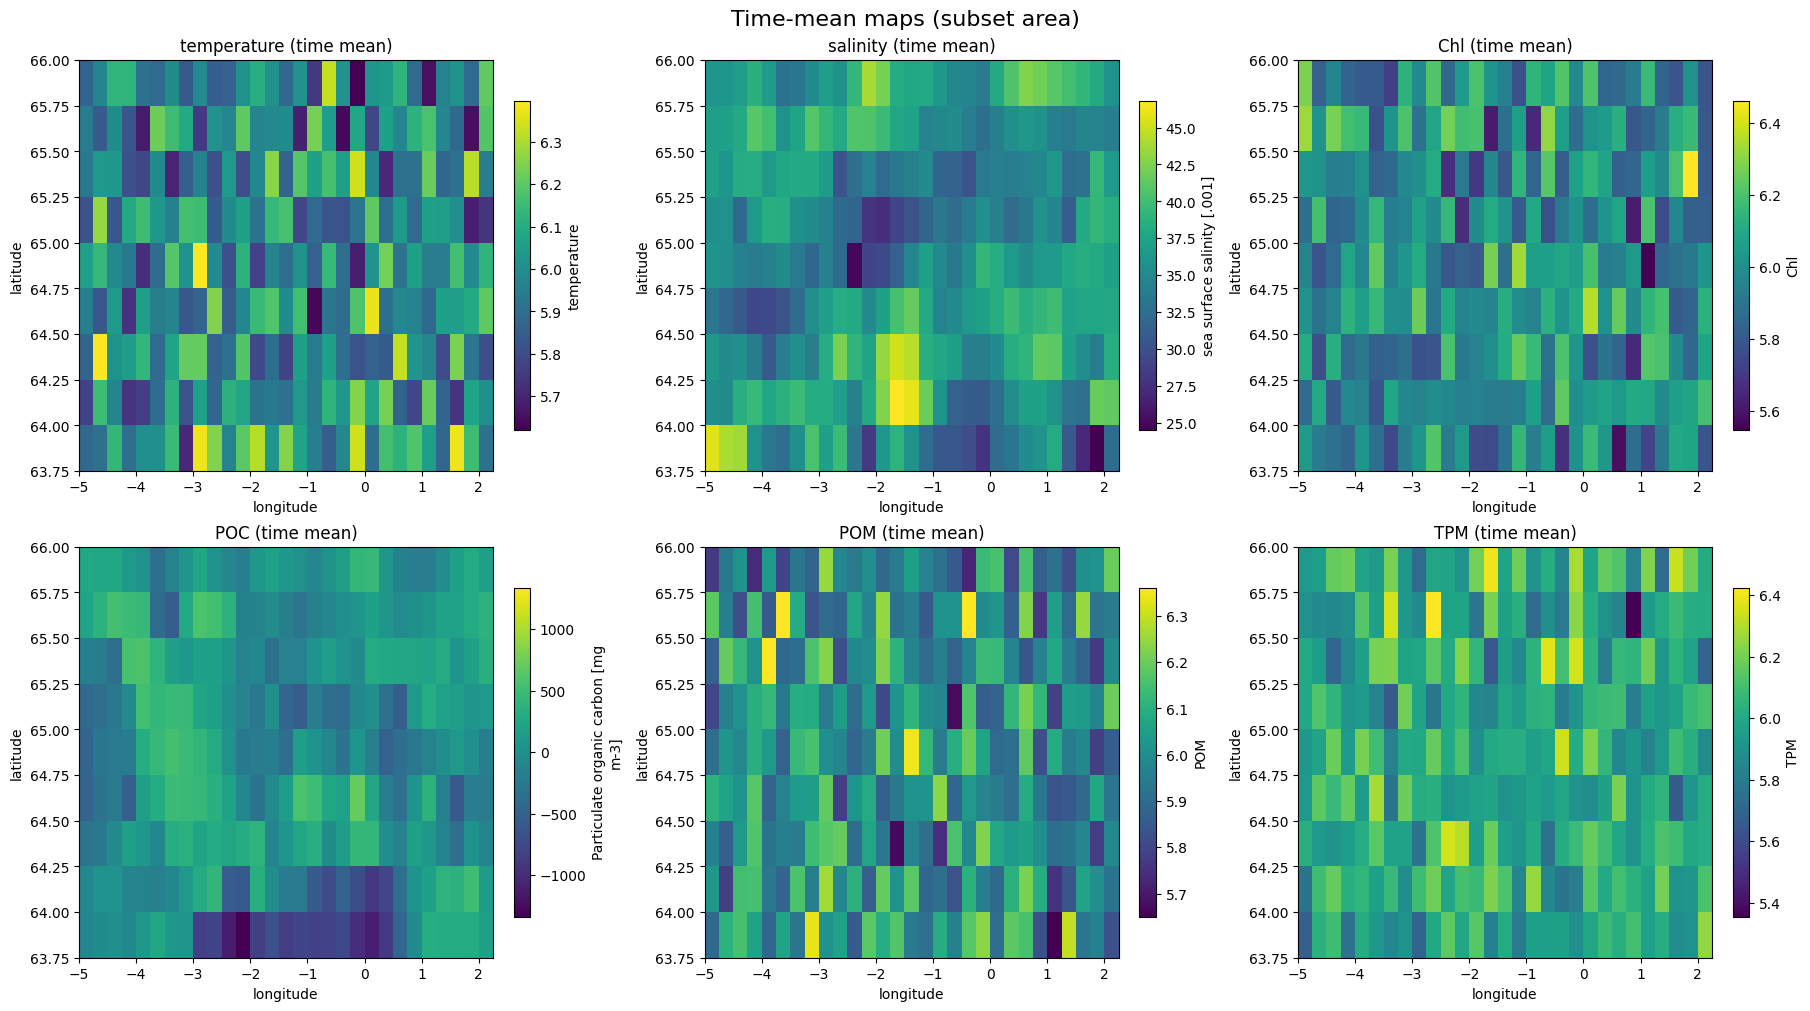

In [17]:
# ============================================================
# EXPLORATORY VISUALISATION OF RAW INPUT DATA
# ============================================================
# Best practice: inspect inputs before running the model.
# This cell produces:
#   1. Six spatial time-mean maps showing geographic patterns
#   2. Temperature/salinity and food-variable time series at
#      the central pixel to check temporal variability.
# If a variable looks flat/random it came from fake-data fallback and model results for it will not be physical.


# Quick guard
if ds_daily is None or len(ds_daily.coords.get('time', [])) == 0:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    # Plot spatial time-mean maps for key variables
    vars_to_map = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    for ax, var in zip(axes, vars_to_map):
        if var in ds_daily:
            try:
                da_mean = ds_daily[var].mean(dim='time')
                im = da_mean.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'shrink': 0.8})
                ax.set_title(f"{var} (time mean)")
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
            except Exception as e:
                ax.text(0.5, 0.5, f"Plot failed: {e}", ha='center')
        else:
            ax.text(0.5, 0.5, f"{var} not found", ha='center')

    plt.suptitle("Time-mean maps (subset area)", fontsize=16)
    # plt.savefig("ds_daily_time_mean_maps.png", dpi=150)
    plt.show()

    # # Time series at a representative point (central pixel)
    # lat0 = float(ds_daily.latitude.mean().values)
    # lon0 = float(ds_daily.longitude.mean().values)
    # point = ds_daily.sel(latitude=lat0, longitude=lon0, method='nearest')

    # fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)

    # # Temperature & Salinity
    # if 'temperature' in point and 'salinity' in point:
    #     axs[0].plot(point['time'].values, point['temperature'].values, label='Temperature (°C)')
    #     axs[0].plot(point['time'].values, point['salinity'].values, label='Salinity (psu)')
    #     axs[0].set_ylabel("Temperature / Salinity")
    #     axs[0].legend()
    #     axs[0].grid(True)
    # else:
    #     axs[0].text(0.5, 0.5, "Temperature or Salinity missing", ha='center')

    # # Food-related variables
    # food_vars = [v for v in ['Chl', 'POC', 'POM', 'TPM'] if v in point]
    # if food_vars:
    #     for v in food_vars:
    #         axs[1].plot(point['time'].values, point[v].values, label=v)
    #     axs[1].set_ylabel("Concentration")
    #     axs[1].legend()
    #     axs[1].grid(True)
    # else:
    #     axs[1].text(0.5, 0.5, "No food variables found", ha='center')

    # plt.xlabel("time")
    # plt.suptitle(f"Time series at nearest point to (lat={lat0:.3f}, lon={lon0:.3f})")
    # plt.savefig("ds_daily_point_timeseries.png", dpi=150)
    # plt.show()

In [18]:

# Prepare variables to plot
vars_to_show = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
available_vars = [v for v in vars_to_show if v in ds_daily]

if len(available_vars) == 0:
    print("No variables available in ds_daily to create folium map.")
else:
    # Map center and bounds
    lat_vals = ds_daily.latitude.values
    lon_vals = ds_daily.longitude.values
    lat_min, lat_max = float(lat_vals.min()), float(lat_vals.max())
    lon_min, lon_max = float(lon_vals.min()), float(lon_vals.max())
    bounds = [[lat_min, lon_min], [lat_max, lon_max]]
    center = [(lat_min + lat_max) / 2.0, (lon_min + lon_max) / 2.0]

    m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

    # Helper to make PNG data URL from 2D array
    def array_to_dataurl(arr2d, cmap_name='viridis', vmin=None, vmax=None, nodata_color=(0, 0, 0, 0)):
        """Convert a 2D numpy array (lat x lon, NaNs allowed) to a data URL PNG using a colormap.
           The array is assumed to be ordered lat increasing -> we flip it vertically for image overlay."""
        mask = np.isnan(arr2d)
        arr = np.array(arr2d, dtype=float)
        if vmin is None:
            vmin = np.nanpercentile(arr, 2) if np.isfinite(np.nanpercentile(arr, 2)) else np.nanmin(arr)
        if vmax is None:
            vmax = np.nanpercentile(arr, 98) if np.isfinite(np.nanpercentile(arr, 98)) else np.nanmax(arr)
        # Avoid zero-range
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
            vmin = np.nanmin(arr)
            vmax = np.nanmax(arr)
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
                vmax = vmin + 1.0

        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
        cmap = mpl.cm.get_cmap(cmap_name)
        mapped = cmap(norm(np.flipud(arr)))  # RGBA float [0,1], flipud so top of image == max latitude

        # Apply transparency where data is nan
        alpha = mapped[..., 3]
        alpha[ np.flipud(mask) ] = 0.0  # flip mask same as data flip
        mapped[..., 3] = alpha

        # Convert to 8-bit RGBA
        rgba8 = (mapped * 255).astype(np.uint8)
        im = Image.fromarray(rgba8, mode='RGBA')

        bio = io.BytesIO()
        im.save(bio, format='PNG')
        b64 = base64.b64encode(bio.getvalue()).decode('ascii')
        return f"data:image/png;base64,{b64}"

    # Optional custom colormaps per variable
    var_cmaps = {
        'temperature': 'viridis',
        'salinity': 'plasma',
        'Chl': 'YlGn',
        'POC': 'YlOrBr',
        'POM': 'OrRd',
        'TPM': 'inferno'
    }

    # Create and add an ImageOverlay per variable (time-mean)
    first_added = False
    for var in available_vars:
        try:
            da_mean = ds_daily[var].mean(dim='time').values
            # Ensure 2D
            if da_mean.ndim != 2:
                # Try to squeeze (sometimes coords order differs)
                da_mean = np.squeeze(da_mean)
                if da_mean.ndim != 2:
                    print(f"Skipping {var}: not 2D after squeeze")
                    continue

            cmap = var_cmaps.get(var, 'viridis')
            vmin = np.nanpercentile(da_mean, 2) if np.isfinite(np.nanpercentile(da_mean, 2)) else None
            vmax = np.nanpercentile(da_mean, 98) if np.isfinite(np.nanpercentile(da_mean, 98)) else None
            data_url = array_to_dataurl(da_mean, cmap_name=cmap, vmin=vmin, vmax=vmax)

            overlay = folium.raster_layers.ImageOverlay(
                name=var,
                image=data_url,
                bounds=bounds,
                opacity=0.8 if not first_added else 1.0,
                interactive=True,
                cross_origin=False,
                zindex=1
            )
            overlay.add_to(m)
            first_added = True

            # Add a small legend using branca linear colormap (approx)
            try:
                # create a linear colormap using vmin/vmax
                lc = linear.__getattribute__(cmap).scale(
                    float(np.nanmin(da_mean)), float(np.nanmax(da_mean))
                )
                lc.caption = f"{var} (time mean)"
                lc.add_to(m)
            except Exception:
                # fallback simple legend using viridis
                pass

        except Exception as e:
            print(f"Failed to add overlay for {var}: {e}")

    # Add LayerControl
    folium.LayerControl(collapsed=False).add_to(m)

    # Inject JavaScript to convert overlay checkboxes into radio buttons so only one overlay can be active at a time.
    # This waits for the layers control to be present and then converts overlay inputs (which are checkboxes)
    # into radio inputs sharing the same name 'overlayGroup', making them mutually exclusive.
    js = """
    <script>
    function makeOverlaysRadio(){
      var lc = document.getElementsByClassName('leaflet-control-layers')[0];
      if(!lc) { setTimeout(makeOverlaysRadio, 200); return; }
      // Get all inputs inside the layers control
      var inputs = lc.querySelectorAll('input');
      // Convert overlay checkboxes to radios. Base layers are already radios (type="radio")
      // Overlays usually have type="checkbox" and are after a <hr> in the control; we simply convert all checkboxes to radios.
      var overlayName = 'overlayGroup';
      for(var i=0; i<inputs.length; i++){
        var inp = inputs[i];
        if(inp.type === 'checkbox'){
          inp.type = 'radio';
          inp.name = overlayName;
        }
      }
    }
    // Run shortly after map init
    setTimeout(makeOverlaysRadio, 500);
    </script>
    """
    from folium import Element
    m.get_root().html.add_child(Element(js))

    # Save to file and report
    out_html = "ds_daily_folium_map.html"
    # m.save(out_html)
    print(f"Folium map saved to {out_html}")


# If in a Jupyter environment, display inline (will be ignored otherwise)
try:
    display(m)
except Exception:
    pass

Folium map saved to ds_daily_folium_map.html


/tmp/ipykernel_147570/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/tmp/ipykernel_147570/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/tmp/ipykernel_147570/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/tmp/ipykernel_147570/1466057462.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated

In [21]:
# ============================================================
# RECHUNK FOR OPTIMAL DASK PERFORMANCE
# ============================================================
# After subsetting and interpolation, Dask's internal chunk
# boundaries may be irregular. Rechunking reorganises them into
# uniform tiles:
#   time: -1  -> one chunk for the full time axis (required;
#               ShellSIM cannot be split along time)
#   lat: 80, lon: 110 -> spatial tile footprint
# After rechunking each Dask task processes one complete tile
# with no overlap, minimising scheduler overhead.
#
# RAM tip: if you encounter MemoryErrors, halve lat/lon chunk
# sizes. Each chunk ~ lat * lon * time_steps * 8 bytes * n_vars.

# Rechunk for optimal performance
# After all the merging and interpolating, Dask's chunks can get fragmented, rechunk so every Dask task receives 
# a data chunk of the exact size

print("Rechunking dataset for optimal performance")
ds_daily = ds_daily.chunk({
    'time': -1,       # Keep all time steps together
    'latitude': 80,   # Process 80 latitudes at once
    'longitude': 110  # Process 110 longitudes at once
})
print("Rechunked dataset")
print(ds_daily.chunks)

Rechunking dataset for optimal performance
Rechunked dataset
Frozen({'time': (365,), 'latitude': (9,), 'longitude': (29,)})


# ShellSIM model wrapper   
takes a 1D numpy array (time-series for one pixel) as input. run entire for loop (time-stepping) and return a 1D numpy array of the result ( eg soft tissue energy time-series). Then Apply in Parallel, using xr.apply_ufunc to apply wrapper function to the gridded data. tell apply_ufunc that the "core dimension" is time, which instructs it to parallelize over all other dimensions (lat, lon)

In [22]:
# ============================================================
# SHELLSIM MODEL CONSTANTS AND WRAPPER FUNCTION
# ============================================================
# N_STATES  = 11 : internal state variables integrated by pyfabm
# N_DIAGS   =  2 : diagnostic outputs (TFW, SL) — from pyfabm
#                  diagnostic_variables, NOT part of model.state
# N_OUTPUTS = 13 : total rows returned per pixel (states + diags)
#
# VARIABLE_NAMES order MUST exactly match the row order filled
# inside the time loop: rows 0–10 = 11 state variables,
# row 11 = TFW, row 12 = SL.
#
# run_fabm_at_point_full (fixes applied):
#   1. Uses len(T_ts) instead of outer-scope time_horizon_len so
#      the function is self-contained and safe in Dask workers.
#   2. Clamps food concentrations (Chl/POC/POM/TPM) to >= 0.
#      Negative concentrations from bad/fake data cause forward-
#      Euler to diverge within a few steps.
#   3. Updates number_of_days_since_start_of_the_year every step
#      so seasonal physiology is correct across the full period.
#   4. redirect_stdout now covers the ENTIRE function body so
#      all FABM print output goes to the log file, not stdout.
# ============================================================

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"

N_STATES  = 11   # pyfabm internal state variables (model.state[:] length)
N_DIAGS   = 2    # diagnostic outputs: TFW (row 11), SL (row 12)
N_OUTPUTS = N_STATES + N_DIAGS  # = 13 — total rows returned per pixel

# Authoritative names list — length must equal N_OUTPUTS (13).
# Method 2 imports this directly; do NOT redefine STATE_NAMES elsewhere.
VARIABLE_NAMES = [
    'soft_tissue_energy', 'shell_energy', 'aging', 'C1', 'C2', 'C3',
    'Chl_state', 'POC_state', 'POM_state', 'TPM_state', 'O2',  # rows 0–10
    'TFW', 'SL'                                                  # rows 11–12
]

assert len(VARIABLE_NAMES) == N_OUTPUTS, (
    f"VARIABLE_NAMES has {len(VARIABLE_NAMES)} entries but N_OUTPUTS={N_OUTPUTS}"
)


def run_fabm_at_point_full(T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts,
                           log_filename):
    """
    Runs the FABM/ShellSIM time-loop for a single spatial pixel.

    Parameters
    ----------
    T_ts, S_ts          : 1-D float arrays, length n_steps
        Temperature (°C) and practical salinity (PSU) time series.
    Chl_ts, POC_ts,
    POM_ts, TPM_ts      : 1-D float arrays, length n_steps
        Food-variable time series (mg m-3).  Values < 0 are clamped
        to 0 before being passed to the model (negative concentrations
        are unphysical and cause forward-Euler divergence).
    log_filename        : str
        Path to the append-mode log file that receives all FABM
        print/diagnostic output (keeps Jupyter stdout clean).

    Returns
    -------
    numpy.ndarray, shape (N_OUTPUTS=13, n_steps)
        Rows  0–10 : pyfabm state variables (model.state[:])
        Row  11    : TFW  diagnostic [g]
        Row  12    : Shell Length diagnostic [cm]
        All-NaN on land pixels or when any input is NaN / non-finite.
    """
    # ── n_steps is taken directly from the input arrays, NOT from the
    #    outer-scope time_horizon_len, so this function is safe to call
    #    from Dask workers that were serialised with a stale closure. ──
    n_steps = len(T_ts)

    # ── Guard: reject land / missing-data pixels ────────────────────
    all_inputs = [T_ts, S_ts, Chl_ts, POC_ts, POM_ts, TPM_ts]
    if any(np.any(np.isnan(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)
    if not all(np.all(np.isfinite(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)

    # ── Clamp food concentrations to physically valid range ─────────
    # Negative concentrations are unphysical (artefacts of linear
    # interpolation or fake test data).  Passing them to the model
    # causes the forward-Euler integration to diverge within a few
    # steps, producing NaN or runaway values for the entire run.
    Chl_ts  = np.maximum(Chl_ts,  0.0)
    POC_ts  = np.maximum(POC_ts,  0.0)
    POM_ts  = np.maximum(POM_ts,  0.0)
    TPM_ts  = np.maximum(TPM_ts,  0.0)

    try:
        # ── redirect_stdout covers the FULL function body so that
        #    pyfabm print output during both init AND getRates() goes
        #    to the log file rather than flooding Jupyter output. ────
        with open(log_filename, 'a') as f_log:
            with redirect_stdout(f_log):

                model = pyfabm.Model(
                    "/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/fabm.yaml"
                )

                # ── Static (time-invariant) dependencies ────────────
                model.cell_thickness = 1.0
                model.dependencies["seeding_rate"].value  = 0.0
                model.dependencies["harvest_ratio"].value = 0.0
                model.dependencies["current_speed"].value = 1.0
                model.dependencies["air_exposure"].value  = 0.0

                # ── Initialise from day-0 forcing values ─────────────
                model.dependencies["temperature"].value        = float(T_ts[0])
                model.dependencies["practical_salinity"].value = float(S_ts[0])
                model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                    pd.Timestamp(time_horizon[0]).dayofyear
                )
                model.findStateVariable('Chl1/Chl').value = float(Chl_ts[0])
                model.findStateVariable('POC1/POC').value = float(POC_ts[0])
                model.findStateVariable('POM1/POM').value = float(POM_ts[0])
                model.findStateVariable('TPM1/TPM').value = float(TPM_ts[0])

                if not model.start():
                    raise RuntimeError("FABM model failed to start internally.")

                # ── Output array ─────────────────────────────────────
                outputs = np.zeros((N_OUTPUTS, n_steps))

                for nd in range(n_steps):
                    # ── Update day-of-year (drives seasonal physiology) ──
                    model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                        pd.Timestamp(time_horizon[nd]).dayofyear
                    )

                    # ── Update environmental forcings ────────────────
                    model.dependencies["temperature"].value        = float(T_ts[nd])
                    model.dependencies["practical_salinity"].value = float(S_ts[nd])
                    model.findStateVariable('Chl1/Chl').value      = float(Chl_ts[nd])
                    model.findStateVariable('POC1/POC').value      = float(POC_ts[nd])
                    model.findStateVariable('POM1/POM').value      = float(POM_ts[nd])
                    model.findStateVariable('TPM1/TPM').value      = float(TPM_ts[nd])

                    # ── Forward-Euler step (same as original 1-D notebook) ──
                    state_rates = model.getRates()
                    model.state[:] += state_rates * 86400.0

                    # ── Guard: catch state blow-up immediately ────────────
                    # If any state variable is NaN or Inf (e.g. from a cube-
                    # root / log of a negative energy reserve when the oyster
                    # starves), pyfabm silently propagates bad values for all
                    # remaining steps without raising an exception.
                    # Detect it here, fill remaining outputs with NaN, and
                    # break — this preserves the valid data already computed
                    # up to this timestep rather than discarding it.
                    if not np.all(np.isfinite(np.array(model.state[:]))):
                        outputs[:, nd:] = np.nan
                        break

                    # ── Store state variables (rows 0–10) ────────────
                    outputs[:N_STATES, nd] = np.array(model.state[:])

                    # ── Store diagnostics (rows 11–12) ───────────────
                    outputs[N_STATES,     nd] = model.diagnostic_variables['Oyster/TFW'].value
                    outputs[N_STATES + 1, nd] = model.diagnostic_variables['Oyster/Shell_Length'].value

        return outputs  # shape (N_OUTPUTS=13, n_steps)

    except RuntimeError:
        warnings.warn(f"FABM failed to start: {pyfabm.getError()}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

    except Exception as e:
        warnings.warn(f"FABM error at pixel: {str(e)}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

## Most optimal processing method:  parallelize over the spatial dimensions (latitude, longitude) using xarray.apply_ufunc.  
chunking only the spatial dimensions (latitude and longitude) tells Dask to split the map into tiles, but keep the full time series for each pixel intact.

In [23]:
# # ============================================================
# # METHOD 1: APPLY_UFUNC — PARALLEL SPATIAL APPLICATION
# # ============================================================
# # xr.apply_ufunc applies run_fabm_at_point_full across every
# # (lat, lon) pixel in parallel via Dask.
# #
# # Key settings:
# #   input_core_dims=[['time']]*6 : time is the 'core' dimension
# #     consumed by the function; Dask parallelises over lat x lon.
# #   output_core_dims=[['state','time']] : wrapper returns (13,T).
# #   vectorize=True : loops pixel-by-pixel (needed for pyfabm).
# #   dask='parallelized' : each spatial chunk becomes a Dask task.
# #
# # --- WHY dask.distributed WITH PROCESSES ---
# # pyfabm holds C-level global state and is NOT thread-safe.
# # Using process-based workers gives each worker its own memory
# # space and its own pyfabm instance, preventing race conditions.
# # n_workers=4, threads_per_worker=2 gives 8 concurrent slots;
# # adjust n_workers to match your CPU count (cpu_count // 2).

# from dask.distributed import Client

# # Start process-based local cluster (thread-safe for pyfabm)
# # IMPORTANT: threads_per_worker MUST be 1.
# # pyfabm has C-level global state that is NOT thread-safe.
# # Two concurrent pyfabm instances in the SAME process (threads)
# # will corrupt each other's model state silently.
# client = Client(n_workers=4, threads_per_worker=1, processes=True)
# print('Dask dashboard:', client.dashboard_link)

# print('Setting up parallel computation with apply_ufunc ...')

# result_full = xr.apply_ufunc(
#     run_fabm_at_point_full,
#     ds_daily['temperature'],   
#     ds_daily['salinity'],
#     ds_daily['Chl'],
#     ds_daily['POC'],
#     ds_daily['POM'],
#     ds_daily['TPM'],
#     input_core_dims=[['time']] * 6,
#     output_core_dims=[['state', 'time']],
#     exclude_dims=set(('time',)),
#     dask='parallelized',
#     vectorize=True,
#     output_dtypes=[float],
#     kwargs={'log_filename': RUN_LOG_FILENAME},
#     dask_gufunc_kwargs={
#         'allow_rechunk': True,
#         'output_sizes': {'state': N_OUTPUTS, 'time': time_horizon_len}
#     }
# )

# # Restore coordinate labels on the output dimensions
# result_full = result_full.assign_coords(time=time_horizon)
# result_full = result_full.assign_coords(state=VARIABLE_NAMES)

# # Promote 'state' coordinate slices into separate Dataset variables
# result_dataset = result_full.to_dataset(dim='state')

# # Attach CF-convention metadata attributes
# result_dataset['soft_tissue_energy'].attrs = {'units': 'J', 'long_name': 'Soft Tissue Energy'}
# result_dataset['shell_energy'].attrs = {'units': 'J', 'long_name': 'Shell Energy'}
# result_dataset['aging'].attrs = {'units': 'days', 'long_name': 'Aging'}
# result_dataset['C1'].attrs = {'units': '', 'long_name': 'C1 State Variable'}
# result_dataset['C2'].attrs = {'units': '', 'long_name': 'C2 State Variable'}
# result_dataset['C3'].attrs = {'units': '', 'long_name': 'C3 State Variable'}
# result_dataset['Chl'].attrs = {'units': 'mg/m3', 'long_name': 'Chlorophyll State'}
# result_dataset['POC'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Carbon State'}
# result_dataset['POM'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Matter State'}
# result_dataset['TPM'].attrs = {'units': 'mg/m3', 'long_name': 'Total Particulate Matter State'}
# result_dataset['O2'].attrs = {'units': 'mg/L', 'long_name': 'Oxygen State'}
# result_dataset['SL'].attrs = {'units': 'cm', 'long_name': 'Shell Length'}
# result_dataset['TFW'].attrs = {'units': 'g', 'long_name': 'Total Fresh Weight'}

# print('\nTask graph built. Result Dataset has 13 variables.')
# print(result_dataset)

# Run computation and Save  
Call .compute() or .to_netcdf() on the result. This triggers Dask to execute the parallel computation and write the final 3D output file.

In [24]:
# ============================================================
# TRIGGER COMPUTATION AND SAVE WITH ZLIB COMPRESSION
# ============================================================
# Calling .to_netcdf() on the Dask-backed Dataset triggers all
# queued tasks and streams results directly to disk so peak RAM
# stays near: one_chunk_size x num_workers.
#
# encoding: enables zlib (deflate) compression at level 4 for
# all 13 output variables. Level 4 gives a good trade-off:
# typically 3-5x size reduction vs uncompressed with negligible
# read-time overhead. chunksizes=(1,65,92) makes single time-
# slice reads contiguous on disk.


# ========================= code to run ===========================
# output_file_name = 'direct_gridded_oyster_output_ALL_STATES.nc'

# # Build compression encoding dict for all 13 output variables
# _compress_enc = {'zlib': True, 'complevel': 4, 'chunksizes': (1, 65, 92)}
# encoding = {var: _compress_enc for var in VARIABLE_NAMES}

# print('Now running dask computation ...')
# with ProgressBar():
#     result_dataset.to_netcdf(output_file_name, compute=True, encoding=encoding)

# print(f' ****** SUCCESS: Results saved to {output_file_name} ******* ')

# # Release distributed workers when done
# client.close()


In [25]:
# ============================================================
# OPTIONAL MEMORY CLEANUP
# ============================================================
# Uncomment these lines after saving to free RAM, especially
# important if continuing to Method 2 or the analysis sections
# below on a machine with limited memory.

# # Clean up
# del ds_poc  
# del ds_sal
# del ds_temp
# del ds_chl
# del ds_pom
# del ds_tpm
# del ds_daily, result_sten
# gc.collect()

# Method 2 on Memory optimization    
Runs in 1:37 ish for start = '02-06-2021' end = '04-06-2021'

TFW and SL are FABM diagnostics (Oyster/TFW, Oyster/Shell_Length) computed inside the model — and the saved file (CELL 40) only writes the 11 state variables, with TFW/SL commented out. So ds_out genuinely has no TFW/SL. To fix the dashboard I need to re-derive them from the saved states (soft_tissue_energy, shell_energy). Let me check whether the ShellSIM/FABM source with the exact allometric constants is available in the workspace

In [26]:
# ============================================================
# METHOD 2 — MEMORY-OPTIMISED BATCHED GRIDDED RUN
# ============================================================
# Key fixes vs the previous version:
#   1. Uses N_OUTPUTS (13) everywhere — NOT N_STATES (11).
#      The wrapper returns 13 rows; telling apply_ufunc to expect
#      11 causes a silent broadcast / shape mismatch error.
#   2. Uses VARIABLE_NAMES (defined in the wrapper cell) as the
#      authoritative 13-entry list so TFW and SL are written.
#   3. Creates netCDF variables for ALL 13 outputs including
#      TFW and SL before the tile loop begins.
#   4. Writes TFW and SL into the output file exactly like the
#      other state variables — no special-casing needed because
#      they are just rows 11–12 of the returned array.
# ============================================================

time_horizon_len = ds_daily.time.size
output_file_name = "gridded_oyster_output_ALL_STATES_batched.nc"

# --- use the authoritative list from the wrapper cell ---
# VARIABLE_NAMES has 13 entries: 11 states + TFW + SL
# N_OUTPUTS = 13  (both defined in the wrapper cell above)

# ============================================================
# CHUNK INFO
# ============================================================
try:
    lat_chunks = ds_daily.chunks['latitude']
    lon_chunks = ds_daily.chunks['longitude']
except Exception:
    raise RuntimeError(
        "ds_daily must be Dask-backed and chunked in latitude/longitude"
    )

lat_indices = np.cumsum([0] + list(lat_chunks))
lon_indices = np.cumsum([0] + list(lon_chunks))

total_lat = int(ds_daily.sizes["latitude"])
total_lon = int(ds_daily.sizes["longitude"])

# ============================================================
# CREATE OUTPUT FILE ONCE — all 13 variables including TFW, SL
# ============================================================
if os.path.exists(output_file_name):
    os.remove(output_file_name)

nc = netCDF4.Dataset(output_file_name, "w", format="NETCDF4")

nc.createDimension("time",      time_horizon_len)
nc.createDimension("latitude",  total_lat)
nc.createDimension("longitude", total_lon)

# coordinate variables
time_var = nc.createVariable("time", "f8", ("time",))
time_seconds = (
    pd.to_datetime(ds_daily.time.values)
    .astype("datetime64[s]")
    .astype(np.int64)
)
time_var[:]       = time_seconds
time_var.units    = "seconds since 1970-01-01 00:00:00"
time_var.calendar = "standard"

lat_var        = nc.createVariable("latitude",  "f4", ("latitude",))
lat_var[:]     = ds_daily.latitude.values.astype(np.float32)
lat_var.units  = getattr(ds_daily["latitude"], "units", "degrees_north")

lon_var        = nc.createVariable("longitude", "f4", ("longitude",))
lon_var[:]     = ds_daily.longitude.values.astype(np.float32)
lon_var.units  = getattr(ds_daily["longitude"], "units", "degrees_east")

# one netCDF variable per output (13 total — states + TFW + SL)
for name in VARIABLE_NAMES:
    v = nc.createVariable(
        name, "f4",
        ("time", "latitude", "longitude"),
        zlib=True, complevel=4,
        fill_value=np.float32(np.nan),
    )
    # attach human-readable metadata
    if name == "TFW":
        v.long_name = "Total Fresh Weight"
        v.units     = "g"
    elif name == "SL":
        v.long_name = "Shell Length"
        v.units     = "cm"

nc.sync()
nc.close()

print(f"Output file created: {output_file_name}")
print(f"Variables to write ({len(VARIABLE_NAMES)}): {VARIABLE_NAMES}\n")
print(f"Starting batched computation -> {output_file_name}")

# ============================================================
# PROCESS TILES AND WRITE
# ============================================================
for i in range(len(lat_chunks)):
    lat_start = int(lat_indices[i])
    lat_end   = int(lat_indices[i + 1])

    for j in range(len(lon_chunks)):
        lon_start = int(lon_indices[j])
        lon_end   = int(lon_indices[j + 1])

        print(
            f"\nBatch Lat {i+1}/{len(lat_chunks)} ({lat_start}:{lat_end})  "
            f"Lon {j+1}/{len(lon_chunks)} ({lon_start}:{lon_end})"
        )

        ds_subset = ds_daily.isel(
            latitude=slice(lat_start, lat_end),
            longitude=slice(lon_start, lon_end),
        )

        # apply_ufunc: vectorize over (lat, lon), keeping time as core dim.
        # output_sizes MUST use N_OUTPUTS (13) — the wrapper returns 13 rows.
        result_full_batch = xr.apply_ufunc(
            run_fabm_at_point_full,
            ds_subset["temperature"],
            ds_subset["salinity"],
            ds_subset["Chl"],
            ds_subset["POC"],
            ds_subset["POM"],
            ds_subset["TPM"],
            input_core_dims=[["time"]] * 6,
            output_core_dims=[["state", "time"]],
            exclude_dims={"time"},
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float],
            kwargs={"log_filename": RUN_LOG_FILENAME},
            dask_gufunc_kwargs={
                "allow_rechunk": True,
                "output_sizes": {
                    "state": N_OUTPUTS,      # <-- 13, not 11
                    "time":  time_horizon_len,
                },
            },
        )

        # Attach coordinate labels so to_dataset(dim='state') works correctly
        result_full_batch = result_full_batch.assign_coords(
            time=ds_subset.time,
            state=VARIABLE_NAMES,            # <-- 13-entry list
        )

        result_dataset_batch = result_full_batch.to_dataset(dim="state")

        with ProgressBar():
            result_dataset_batch.load()

        # ── Debug summary ──
        print("\nChunk output summary:")
        for var_name in VARIABLE_NAMES:
            arr    = result_dataset_batch[var_name].values
            total  = arr.size
            nans   = np.isnan(arr).sum()
            try:
                lo, hi = np.nanmin(arr), np.nanmax(arr)
            except ValueError:
                lo = hi = np.nan
            print(
                f"  {var_name:22s}  NaN%={100*nans/total:6.2f}  "
                f"min={lo:.4g}  max={hi:.4g}"
            )

        # ── Write tile into pre-created netCDF ──
        nc = netCDF4.Dataset(output_file_name, "r+")
        try:
            for var_name in VARIABLE_NAMES:
                da = result_dataset_batch[var_name]

                # Identify dim names (apply_ufunc may return lat/lon in any order)
                dims     = list(da.dims)
                time_dim = next(d for d in dims if "time" in d.lower())
                lat_dim  = next(d for d in dims if "lat"  in d.lower())
                lon_dim  = next(d for d in dims if "lon"  in d.lower())

                arr = (
                    da.transpose(time_dim, lat_dim, lon_dim)
                    .values
                    .astype(np.float32)
                )

                if arr.shape[0] != time_horizon_len:
                    raise ValueError(
                        f"Time-axis mismatch for '{var_name}': "
                        f"got {arr.shape[0]}, expected {time_horizon_len}. "
                        f"Full shape: {arr.shape}"
                    )

                nc.variables[var_name][
                    :, lat_start:lat_end, lon_start:lon_end
                ] = arr

                print(
                    f"  Wrote {var_name:22s}  shape={arr.shape}  "
                    f"NaNs={np.isnan(arr).sum()}"
                )

            nc.sync()
        finally:
            nc.close()

        del result_full_batch, result_dataset_batch, ds_subset
        gc.collect()

print(f"\n✅ Success: all batches processed and saved to {output_file_name}")

Output file created: gridded_oyster_output_ALL_STATES_batched.nc
Variables to write (13): ['soft_tissue_energy', 'shell_energy', 'aging', 'C1', 'C2', 'C3', 'Chl_state', 'POC_state', 'POM_state', 'TPM_state', 'O2', 'TFW', 'SL']

Starting batched computation -> gridded_oyster_output_ALL_STATES_batched.nc

Batch Lat 1/1 (0:9)  Lon 1/1 (0:29)
[########################################] | 100% Completed | 6.33 sms

Chunk output summary:
  soft_tissue_energy      NaN%= 26.44  min=1062  max=2.981e+04
  shell_energy            NaN%= 26.44  min=519  max=9671
  aging                   NaN%= 26.44  min=1  max=1
  C1                      NaN%= 26.44  min=2.896e-11  max=100
  C2                      NaN%= 26.44  min=0  max=47.69
  C3                      NaN%= 26.44  min=0  max=100
  Chl_state               NaN%= 26.44  min=1  max=11
  POC_state               NaN%= 26.44  min=0  max=1805
  POM_state               NaN%= 26.44  min=1  max=11
  TPM_state               NaN%= 26.44  min=1  max=11
  O2   

Plotting time series for point: Lat=64.888511, Lon=-1.314628
Nearest pixel found at: Lat=64.875, Lon=-1.375


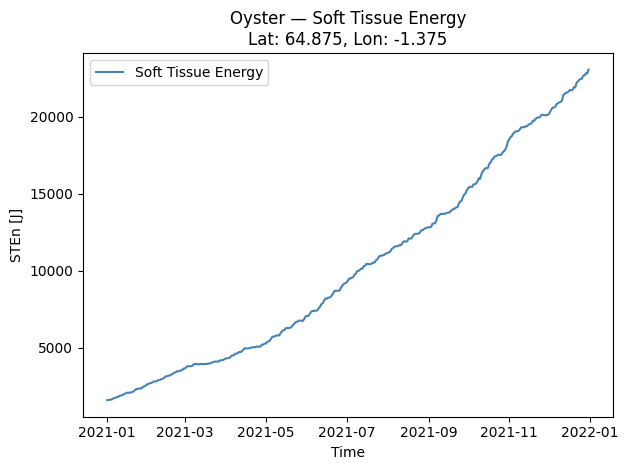

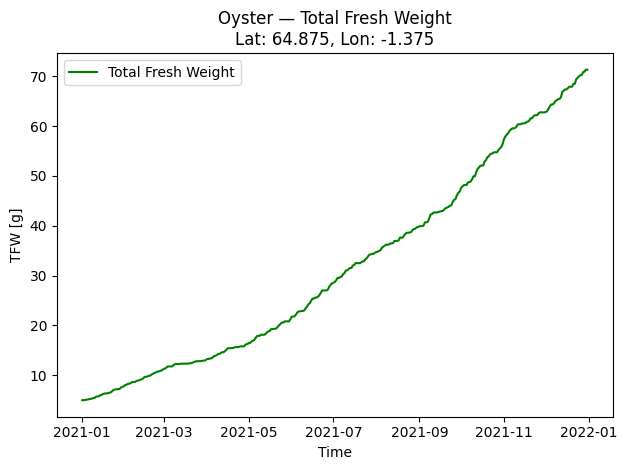

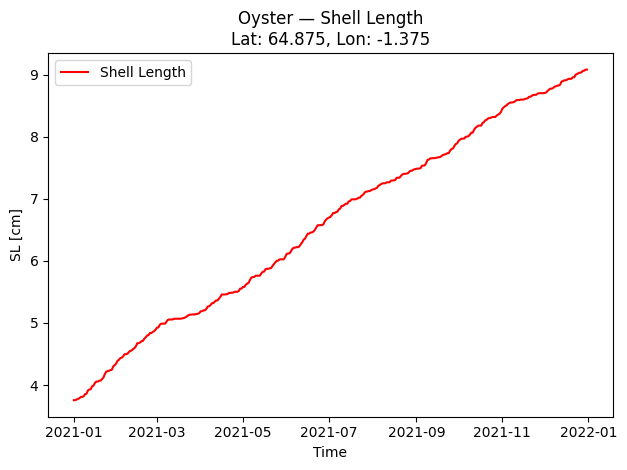

In [27]:
# ============================================================
# SINGLE-POINT TIME SERIES PLOTS
# ============================================================
# Reads directly from the saved netCDF output file so results
# are persistent across kernel restarts and cover all batches.
# result_dataset is NOT used here — it only holds the last
# tile in memory and is discarded after the batch loop.
# ============================================================

OUTPUT_FILE = "gridded_oyster_output_ALL_STATES_batched.nc"

# Mask sentinel error values (-99) and non-finite values written
# by ShellSIM on pixels that failed internally.
ds_out = xr.open_dataset(OUTPUT_FILE)
ds_out = ds_out.where(ds_out > -90)          # mask ShellSIM -99 sentinels
for var in ds_out.data_vars:
    ds_out[var] = ds_out[var].where(np.isfinite(ds_out[var].values))

plot_lat = 64.888511
plot_lon = -1.314628
print(f"Plotting time series for point: Lat={plot_lat}, Lon={plot_lon}")

try:
    single_point_data = ds_out.sel(
        latitude=plot_lat,
        longitude=plot_lon,
        method='nearest'
    ).load()

    actual_lat = float(single_point_data.latitude)
    actual_lon = float(single_point_data.longitude)
    print(f"Nearest pixel found at: Lat={actual_lat:.3f}, Lon={actual_lon:.3f}")

    all_nan = single_point_data.soft_tissue_energy.isnull().all()
    if all_nan:
        print("⚠️  Data at this point is all NaN (land or missing input data).")
        print("   Try a different coordinate — see the data coverage map cell.")

    # ── Plot 1: Soft Tissue Energy ──
    fig1, ax1 = plt.subplots()
    ax1.plot(single_point_data.time, single_point_data.soft_tissue_energy,
             label='Soft Tissue Energy', color='steelblue')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('STEn [J]')
    ax1.set_title(f'Oyster — Soft Tissue Energy\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax1.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Total Fresh Weight ──
    fig2, ax2 = plt.subplots()
    ax2.plot(single_point_data.time, single_point_data.TFW,
             label='Total Fresh Weight', color='green')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('TFW [g]')
    ax2.set_title(f'Oyster — Total Fresh Weight\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 3: Shell Length ──
    fig3, ax3 = plt.subplots()
    ax3.plot(single_point_data.time, single_point_data.SL,
             label='Shell Length', color='red')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('SL [cm]')
    ax3.set_title(f'Oyster — Shell Length\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax3.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error selecting data for plotting: {e}")
    print("Check that the output file exists and the coordinates fall within the domain.")

In [28]:
result_dataset = ds_out

In [29]:
result_dataset


<xarray.Dataset> Size: 5MB
Dimensions:             (time: 365, latitude: 9, longitude: 29)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-31
  * latitude            (latitude) float32 36B 63.88 64.12 64.38 ... 65.62 65.88
  * longitude           (longitude) float32 116B -4.875 -4.625 ... 1.875 2.125
Data variables: (12/13)
    soft_tissue_energy  (time, latitude, longitude) float32 381kB 1.609e+03 ....
    shell_energy        (time, latitude, longitude) float32 381kB 522.3 ... 7...
    aging               (time, latitude, longitude) float32 381kB 1.0 ... 1.0
    C1                  (time, latitude, longitude) float32 381kB 99.68 ... 2...
    C2                  (time, latitude, longitude) float32 381kB 0.316 ... 0...
    C3                  (time, latitude, longitude) float32 381kB 0.0 ... 99.99
    ...                  ...
    POC_state           (time, latitude, longitude) float32 381kB 0.0 ... 28.0
    POM_state           (time, latitude, longitude) float32 381kB 1.369 ... 7...
    TPM_state           (time, latitude, longitude) float32 381kB 3.458 ... 4...
    O2                  (time, latitude, longitude) float32 381kB 10.0 ... 10.0
    TFW                 (time, latitude, longitude) float32 381kB 5.0 ... 68.54
    SL                  (time, latitude, longitude) float32 381kB 3.757 ... 8.96

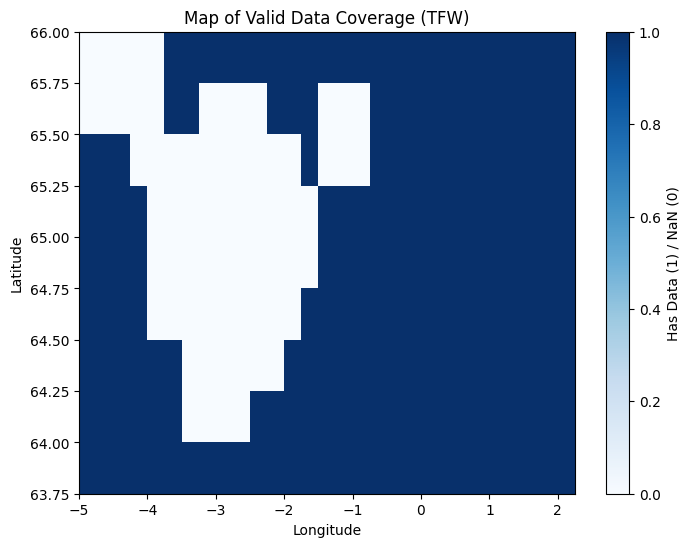


Examine the map above to visually pick a coordinate (blue area) to plot.


In [30]:
# ============================================================
# DATA COVERAGE MAP
# ============================================================
# Creates a spatial map showing which pixels contain valid
# (non-NaN) model output vs which are all-NaN (land or where
# all inputs were missing). Blue pixels = valid model output;
# white pixels = no data. Use this map to identify regions
# suitable for aquaculture analysis.

# 1. Create a boolean map: True if a pixel has ANY non-NaN data over time
#    .any(dim='time') collapses the time dimension, leaving only (lat, lon)
data_coverage = ~result_dataset['TFW'].isnull().all(dim='time')

# 2. Plot the coverage map
plt.figure(figsize=(8, 6))
# We use .plot() from xarray directly for simplicity
data_coverage.plot(
    cmap='Blues', 
    cbar_kwargs={'label': 'Has Data (1) / NaN (0)'}
)
plt.title('Map of Valid Data Coverage (TFW)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\nExamine the map above to visually pick a coordinate (blue area) to plot.")

# Section 2

## Read and explore produced output

---
## Point Insight Section
The following cells provide a deep-dive analysis for a **single user-selected (lat, lon) point**.
Run the valid-point-finder cells above first to identify a coordinate with non-NaN model output,
then set `insight_lat` and `insight_lon` in Cell A before running this section.

These insights answer the practical question: *How well would an oyster farm perform at this exact location?*

## Point Insight Dashboard
A 6-panel summary figure giving an at-a-glance view of oyster growth at the selected point.
Each panel highlights a different aspect of performance: energy content, commercial weight,
shell length, daily growth rate, cumulative weight gain, and seasonal patterns.
This is the first plot a stakeholder should see when evaluating a candidate farm site.

In [59]:
HARVEST_SL_CM = 6.0  # cm — standard harvest shell length
MARKET_WEIGHT_G = 20.0  # grams — typical marketable size threshold

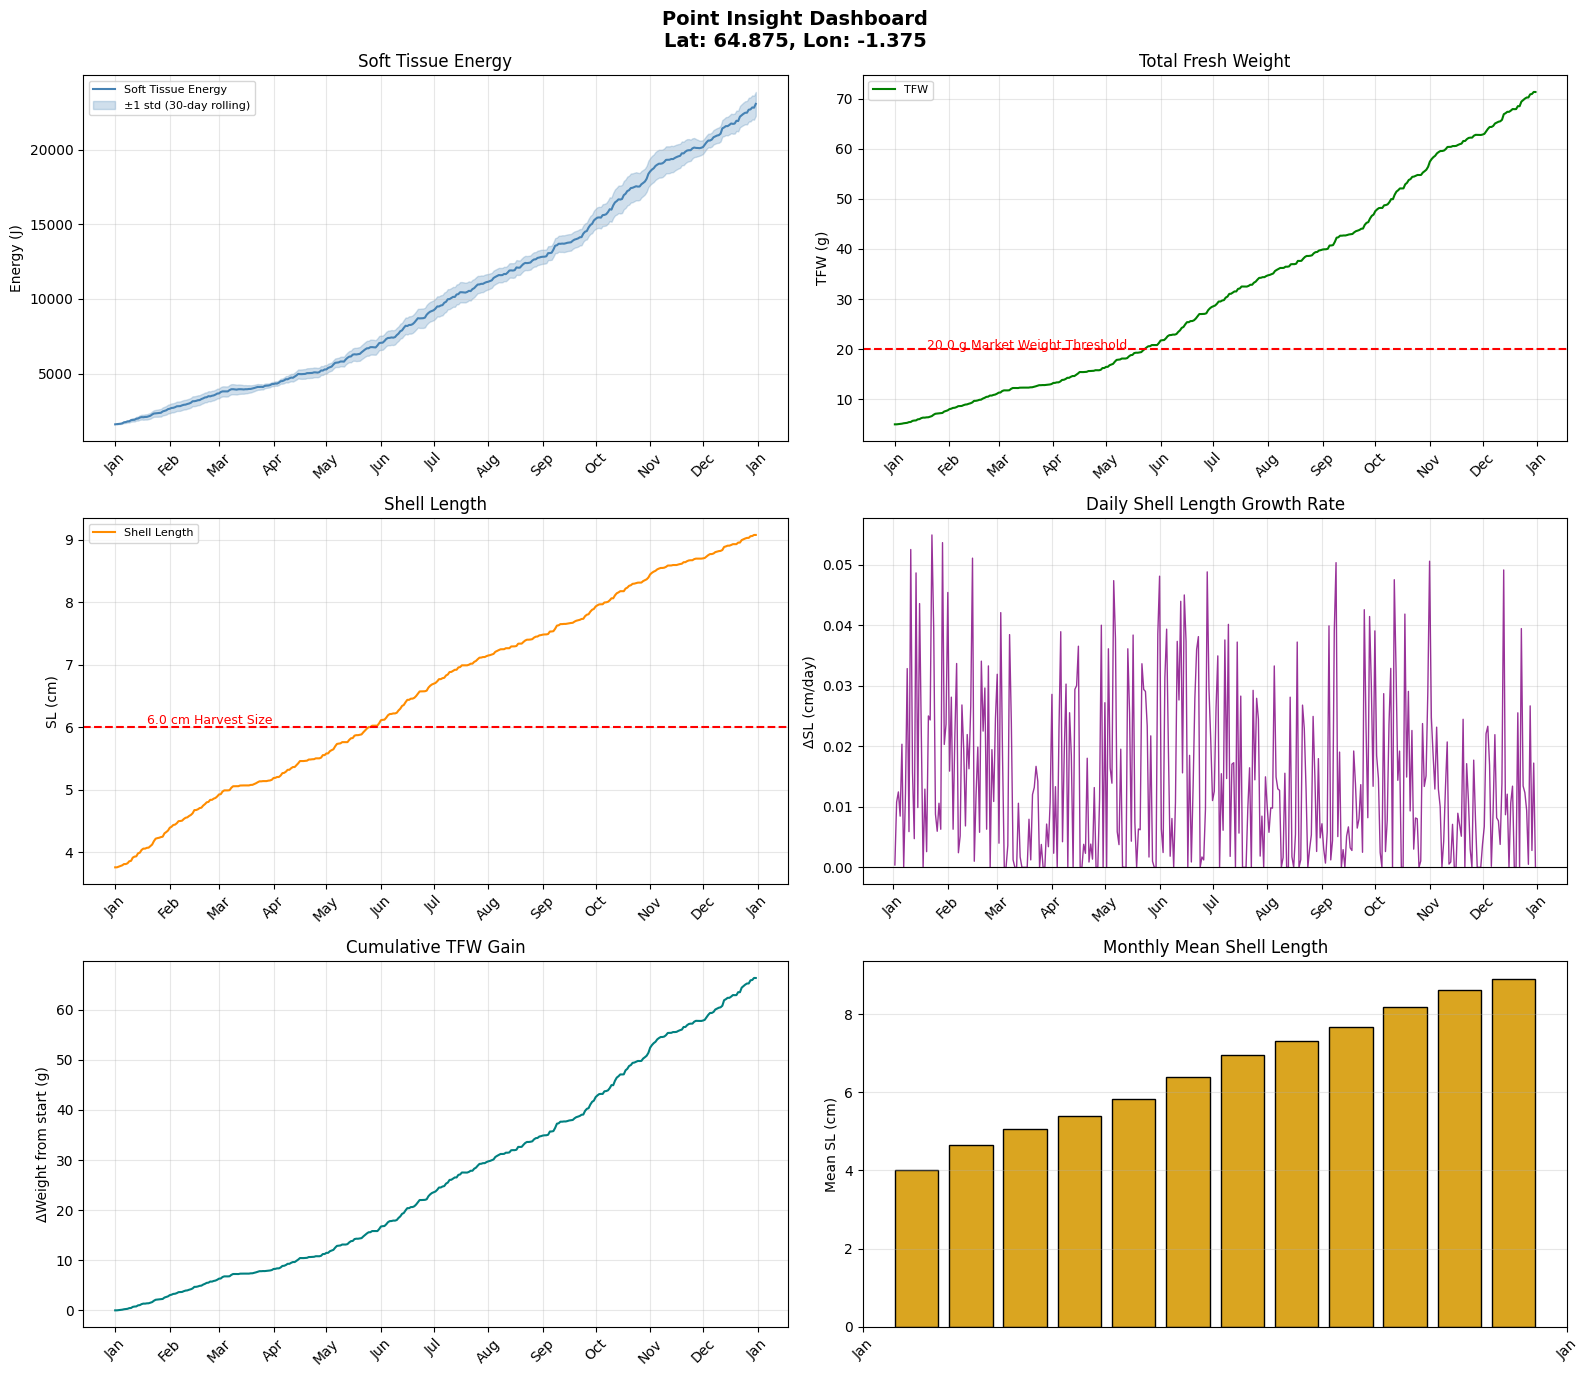

Saved: point_insight_dashboard.png


In [46]:
# ============================================================
# CELL A: POINT INSIGHT DASHBOARD — 6-PANEL FIGURE
# ============================================================
# Extracts the full time series for a single (lat, lon) point
# and plots 6 panels covering key growth indicators.
# Set insight_lat and insight_lon to the valid point found above.

# # --- User inputs: set these to your point of interest ---
# insight_lat = new_plot_lat  # replace with a valid lat if new_plot_lat is undefined
# insight_lon = new_plot_lon  # replace with a valid lon if new_plot_lon is undefined


# --- User inputs: set these to your point of interest ---
insight_lat = 64.888511  # replace with a valid lat if new_plot_lat is undefined
insight_lon = -1.314628  # replace with a valid lon if new_plot_lon is undefined

# Load just this pixel's data into memory
pt = result_dataset.sel(
    latitude=insight_lat, longitude=insight_lon, method='nearest'
).load()

# Extract 1-D numpy arrays for convenience
times     = pt.time.values
ste       = pt['soft_tissue_energy'].values.astype(float)
tfw       = pt['TFW'].values.astype(float)
sl        = pt['SL'].values.astype(float)

# Compute derived series
sl_growth_rate   = np.concatenate([[np.nan], np.diff(sl)])   # daily SL change (cm/day)
tfw_cumulative   = tfw - np.nanmean(tfw[:1])                 # cumulative TFW gain from start

# Monthly mean SL for bar chart (Panel 6)
times_pd  = pd.DatetimeIndex(times)
df_monthly = pd.DataFrame({'SL': sl, 'month': times_pd.month})
monthly_sl = df_monthly.groupby('month')['SL'].mean()

# Rolling 30-day std for STEn shaded band (Panel 1)
ste_series = pd.Series(ste, index=times_pd)
ste_roll_std = ste_series.rolling(30, min_periods=1).std().values

# ---- Build 3x2 figure ----
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()

# Panel 1: Soft Tissue Energy with ±1 std band
ax = axes[0]
ax.plot(times, ste, color='steelblue', linewidth=1.5, label='Soft Tissue Energy')
ax.fill_between(times, ste - ste_roll_std, ste + ste_roll_std,
                alpha=0.25, color='steelblue', label='±1 std (30-day rolling)')
ax.set_title('Soft Tissue Energy')
ax.set_ylabel('Energy (J)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Total Fresh Weight with market threshold line

ax = axes[1]
ax.plot(times, tfw, color='green', linewidth=1.5, label='TFW')
ax.axhline(MARKET_WEIGHT_G, color='red', linestyle='--', linewidth=1.5)
ax.text(times[len(times)//20], MARKET_WEIGHT_G + 0.05,
        f'{MARKET_WEIGHT_G} g Market Weight Threshold', color='red', fontsize=9)
ax.set_title('Total Fresh Weight')
ax.set_ylabel('TFW (g)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Shell Length with harvest size line

ax = axes[2]
ax.plot(times, sl, color='darkorange', linewidth=1.5, label='Shell Length')
ax.axhline(HARVEST_SL_CM, color='red', linestyle='--', linewidth=1.5)
ax.text(times[len(times)//20], HARVEST_SL_CM + 0.05,
        f'{HARVEST_SL_CM} cm Harvest Size', color='red', fontsize=9)
ax.set_title('Shell Length')
ax.set_ylabel('SL (cm)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Daily SL growth rate
ax = axes[3]
ax.plot(times, sl_growth_rate, color='purple', linewidth=1.0, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_title('Daily Shell Length Growth Rate')
ax.set_ylabel('ΔSL (cm/day)')
ax.grid(True, alpha=0.3)

# Panel 5: Cumulative TFW gain
ax = axes[4]
ax.plot(times, tfw_cumulative, color='teal', linewidth=1.5)
ax.set_title('Cumulative TFW Gain')
ax.set_ylabel('ΔWeight from start (g)')
ax.grid(True, alpha=0.3)

# Panel 6: Monthly bar chart of mean SL
ax = axes[5]
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(monthly_sl.index, monthly_sl.values, color='goldenrod', edgecolor='black')
ax.set_xticks(monthly_sl.index)
ax.set_xticklabels([month_names[m-1] for m in monthly_sl.index], rotation=45)
ax.set_title('Monthly Mean Shell Length')
ax.set_ylabel('Mean SL (cm)')
ax.grid(True, alpha=0.3, axis='y')

# ── Readable monthly x-axis ticks for all panels ──────────────────
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    f'Point Insight Dashboard\n'
    f'Lat: {pt.latitude.item():.3f}, Lon: {pt.longitude.item():.3f}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
# plt.savefig('point_insight_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: point_insight_dashboard.png')

## Point Statistical Summary
A concise table summarising key statistics for the three most important output variables
(Soft Tissue Energy, Total Fresh Weight, Shell Length) at the selected point.
This lets a farm manager quickly compare candidate sites without reading plots.

In [41]:
# ============================================================
# CELL B: POINT STATISTICAL SUMMARY TABLE
# ============================================================
# Computes summary statistics for soft_tissue_energy, TFW, SL
# at the selected pixel and prints them as a pandas DataFrame.
# Uses skipna=True / np.nanXxx to handle any residual NaNs.

# Map variable names to arrays already extracted in Cell A
stat_vars = {
    'soft_tissue_energy': ste,
    'TFW':                tfw,
    'SL':                 sl,
}

rows = {}
for vname, arr in stat_vars.items():
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        rows[vname] = {'min': np.nan, 'max': np.nan, 'mean': np.nan,
                       'std': np.nan, 'final_value': np.nan,
                       'peak_date': 'N/A', 'days_above_median': 0}
        continue
    median_val  = np.nanmedian(arr)
    peak_idx    = np.nanargmax(arr)
    rows[vname] = {
        'min':              round(float(np.nanmin(arr)), 4),
        'max':              round(float(np.nanmax(arr)), 4),
        'mean':             round(float(np.nanmean(arr)), 4),
        'std':              round(float(np.nanstd(arr)), 4),
        'final_value':      round(float(arr[-1]), 4),
        'peak_date':        str(pd.Timestamp(times[peak_idx]).date()),
        'days_above_median': int(np.sum(arr > median_val)),
    }

df_stats = pd.DataFrame(rows).T
print('=== Point Statistical Summary ===')
print(f'Location: Lat {pt.latitude.item():.3f}, Lon {pt.longitude.item():.3f}')
print()
print(df_stats.to_string())


=== Point Statistical Summary ===
Location: Lat 64.875, Lon -1.375

                          min         max        mean      std final_value   peak_date days_above_median
soft_tissue_energy  1599.8892  23055.6738  10229.9509   6350.2  23055.6738  2021-12-31               182
TFW                       5.0     71.3295     31.6767  19.8177     71.3193  2021-12-30               182
SL                     3.7567      9.0801      6.5891   1.5449      9.0801  2021-12-30               182


## Point Harvest Readiness
Answers the central commercial question: *When will the oysters at this site be ready to harvest?*
Reports the first date each size threshold is crossed and the fraction of the model period
when both conditions are met simultaneously.

In [42]:
# ============================================================
# CELL C: POINT HARVEST READINESS
# ============================================================
# Identifies threshold crossing dates and the fraction of the
# modelled period when both SL>=6 cm AND TFW>=5 g are satisfied.



# Convert time array to pandas DatetimeIndex for easy formatting
times_pd = pd.DatetimeIndex(times)

# First date SL reaches harvest size
sl_ready_mask = sl >= HARVEST_SL_CM
if sl_ready_mask.any():
    first_sl_date  = times_pd[sl_ready_mask][0]
    days_to_sl     = (first_sl_date - times_pd[0]).days
else:
    first_sl_date  = None
    days_to_sl     = None

# First date TFW reaches market weight
tfw_ready_mask = tfw >= MARKET_WEIGHT_G
if tfw_ready_mask.any():
    first_tfw_date = times_pd[tfw_ready_mask][0]
    days_to_tfw    = (first_tfw_date - times_pd[0]).days
else:
    first_tfw_date = None
    days_to_tfw    = None

# Fraction of period where BOTH thresholds are simultaneously met
both_ready_mask = sl_ready_mask & tfw_ready_mask
pct_both_ready  = 100.0 * np.sum(both_ready_mask) / len(sl)

print('=== Point Harvest Readiness ===')
print(f'Location : Lat {pt.latitude.item():.3f}, Lon {pt.longitude.item():.3f}')
print(f'Period   : {str(times_pd[0].date())} to {str(times_pd[-1].date())}')
print()
if first_sl_date:
    print(f'First date SL >= {HARVEST_SL_CM} cm  : {first_sl_date.date()} ({days_to_sl} days from start)')
else:
    print(f'SL NEVER reached {HARVEST_SL_CM} cm within the model period')
if first_tfw_date:
    print(f'First date TFW >= {MARKET_WEIGHT_G} g  : {first_tfw_date.date()} ({days_to_tfw} days from start)')
else:
    print(f'TFW NEVER reached {MARKET_WEIGHT_G} g within the model period')
print()
print(f'% of period when BOTH thresholds met : {pct_both_ready:.1f}%')


=== Point Harvest Readiness ===
Location : Lat 64.875, Lon -1.375
Period   : 2021-01-01 to 2021-12-31

First date SL >= 6.0 cm  : 2021-05-25 (144 days from start)
First date TFW >= 20.0 g  : 2021-05-23 (142 days from start)

% of period when BOTH thresholds met : 60.5%


## Point Seasonal Breakdown
Groups the time series by calendar month to show seasonal growth patterns.
Understanding which months have the best growth conditions helps optimise
seeding and harvest schedules.

=== Monthly Mean SL (cm) and TFW (g) ===
           SL        TFW
Jan  4.018211   6.193722
Feb  4.640479   9.512896
Mar  5.066214  12.327268
Apr  5.391228  14.886766
May  5.834329  18.909718
Jun  6.388090  24.847120
Jul  6.942011  31.837754
Aug  7.313979  37.234356
Sep  7.666946  42.916574
Oct  8.169180  51.943035
Nov  8.603230  60.665037
Dec  8.901847  67.237071


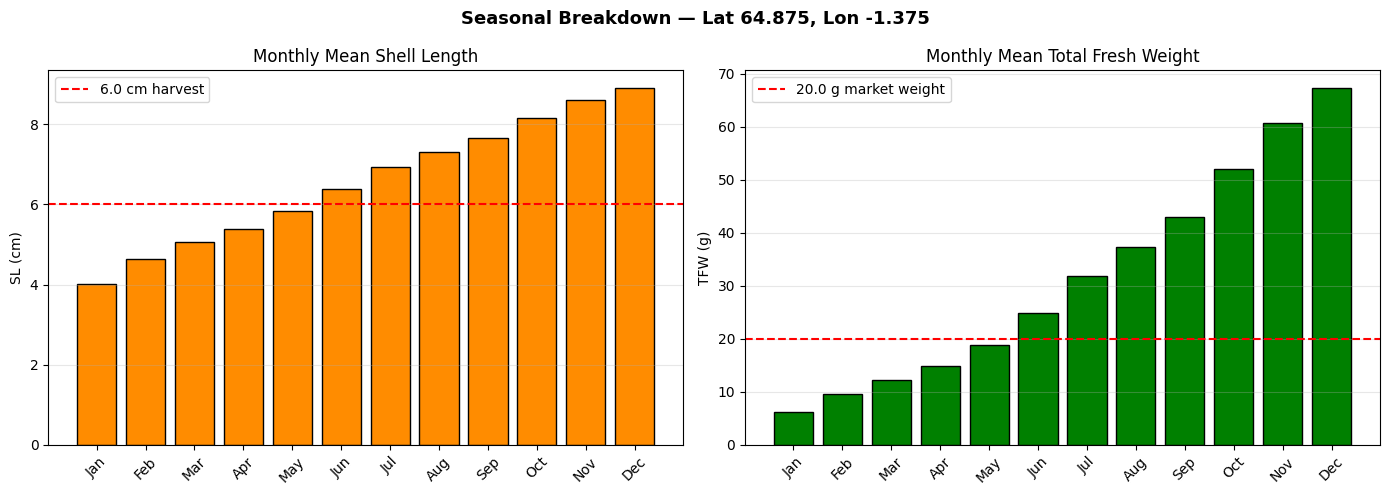

Saved: point_seasonal_breakdown.png


In [44]:
# ============================================================
# CELL D: POINT SEASONAL BREAKDOWN
# ============================================================
# Groups SL and TFW by calendar month, computes monthly means,
# prints a summary table, and plots grouped bar charts.

times_pd = pd.DatetimeIndex(times)
df_season = pd.DataFrame({
    'month': times_pd.month,
    'SL':    sl,
    'TFW':   tfw,
})

monthly_means = df_season.groupby('month')[['SL', 'TFW']].mean()

# Print summary table
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_means.index = [month_names[m-1] for m in monthly_means.index]
print('=== Monthly Mean SL (cm) and TFW (g) ===')
print(monthly_means.to_string())

# Bar chart for each variable side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_means.index, monthly_means['SL'],
            color='darkorange', edgecolor='black')
axes[0].axhline(HARVEST_SL_CM, color='red', linestyle='--', label=f'{HARVEST_SL_CM} cm harvest')
axes[0].set_title('Monthly Mean Shell Length')
axes[0].set_ylabel('SL (cm)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(monthly_means.index, monthly_means['TFW'],
            color='green', edgecolor='black')
axes[1].axhline(MARKET_WEIGHT_G, color='red', linestyle='--', label=f'{MARKET_WEIGHT_G} g market weight')
axes[1].set_title('Monthly Mean Total Fresh Weight')
axes[1].set_ylabel('TFW (g)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Seasonal Breakdown — Lat {pt.latitude.item():.3f}, Lon {pt.longitude.item():.3f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
# plt.savefig('point_seasonal_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: point_seasonal_breakdown.png')


---
## Bounding Box (BBox) Area Insights Section
The following cells analyse model output across a **user-defined geographic bounding box**
and date range. This simulates the workflow where a user draws a rectangle on a map,
picks a season, and asks: *Which parts of this region are best for oyster farming?*

Set `user_bbox` and date range in **Cell E** before running the remaining cells.

## BBox Setup
Define the bounding box and date range, then subset `result_dataset` to that region and period.
All subsequent BBox cells operate on `ds_bbox` — a small, fully loaded in-memory Dataset.

## BBox: Data Availability Pre-flight Check

Before drawing your analysis bbox, you **must** know where the model actually produced
non-NaN output. Any pixel that had a NaN in *any* of the 6 input variables (T, S, Chl, POC,
POM, TPM) was skipped by the model and returns NaN in `result_dataset`.

Real satellite products (e.g. CMEMS POC) have land-masks and observation gaps — those
holes propagate directly into model output. Run this cell first to see a map of valid
coverage, then pick your bbox from a blue region.

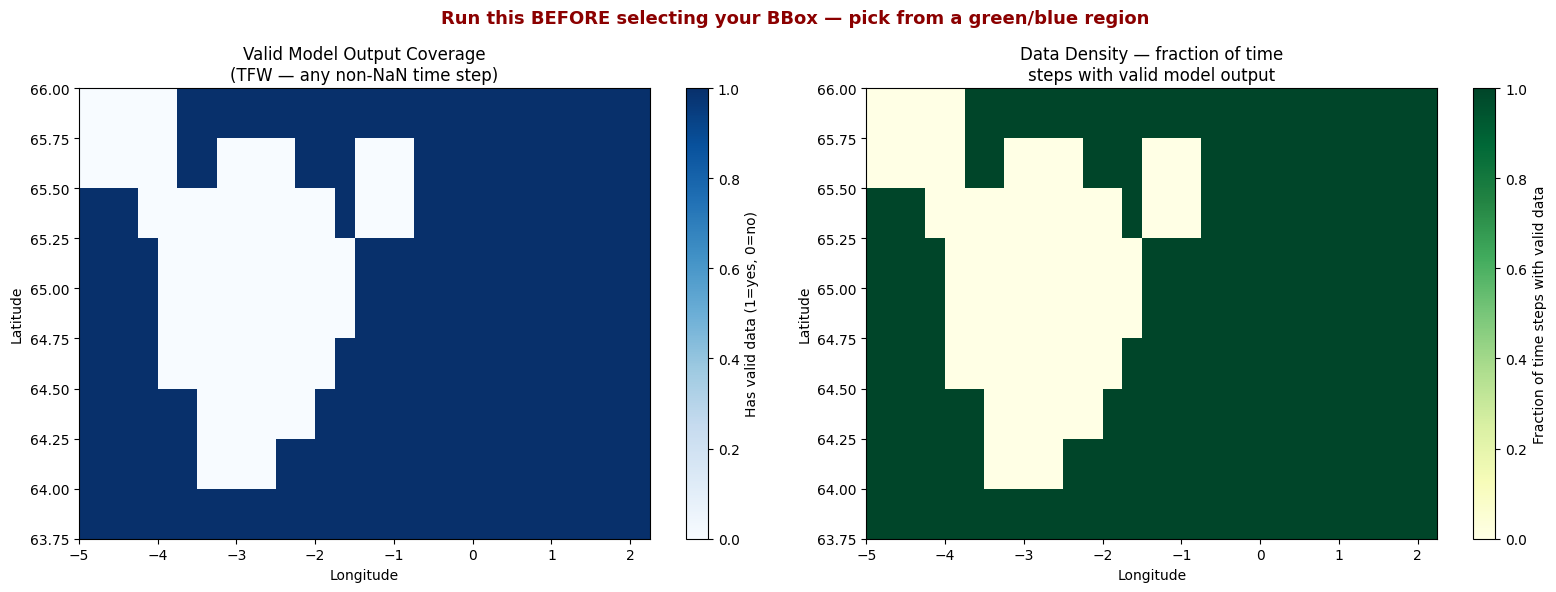

Saved: valid_data_coverage_map.png

✅ Valid data region (where model output is non-NaN):
   Lat  : 63.88° to 65.88°
   Lon  : -4.88° to 2.12°
   Use these bounds to define user_bbox in Cell E below.


In [47]:
# ============================================================
# DATA AVAILABILITY MAP — find where the model produced valid output
# ============================================================
# For every (lat, lon) pixel we check whether the model produced
# ANY non-NaN value over the full time period.
# Pixels over land, or where satellite data had gaps, will be NaN.
# Only pick a bbox from the coloured (valid) region below.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Build a boolean mask: True = at least one valid time step for TFW
valid_mask = ~result_dataset['TFW'].isnull().all(dim='time')
valid_frac  = (~result_dataset['TFW'].isnull()).mean(dim='time')  # fraction of time steps valid

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left panel: binary coverage (has data / no data) ---
ax = axes[0]
valid_mask.plot(ax=ax, cmap='Blues', add_colorbar=True,
                cbar_kwargs={'label': 'Has valid data (1=yes, 0=no)'})
ax.set_title('Valid Model Output Coverage\n(TFW — any non-NaN time step)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# --- Right panel: fraction of time with valid data ---
ax = axes[1]
valid_frac.plot(ax=ax, cmap='YlGn', vmin=0, vmax=1, add_colorbar=True,
                cbar_kwargs={'label': 'Fraction of time steps with valid data'})
ax.set_title('Data Density — fraction of time\nsteps with valid model output')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.suptitle('Run this BEFORE selecting your BBox — pick from a green/blue region',
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
# plt.savefig('valid_data_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: valid_data_coverage_map.png')

# ── Print coordinate bounds of the valid region ──────────────────────────────
valid_vals = valid_mask.values.astype(bool)
valid_lats = result_dataset.latitude.values[valid_vals.any(axis=1)]
valid_lons = result_dataset.longitude.values[valid_vals.any(axis=0)]

if len(valid_lats) > 0 and len(valid_lons) > 0:
    print(f'\n✅ Valid data region (where model output is non-NaN):')
    print(f'   Lat  : {valid_lats.min():.2f}° to {valid_lats.max():.2f}°')
    print(f'   Lon  : {valid_lons.min():.2f}° to {valid_lons.max():.2f}°')
    print(f'   Use these bounds to define user_bbox in Cell E below.')
else:
    print('❌ No valid data found anywhere in result_dataset.')
    print('   Check that run_fabm_at_point_full succeeded and ds_daily has non-NaN inputs.')


In [48]:
# ============================================================
# AUTO-SUGGEST BBOX FROM VALID DATA
# ============================================================
# Finds the centroid of the valid-data region and proposes a
# ~5°×5° window around it as a starter bbox for the analysis.
# Adjust user_bbox_auto manually if you want a different region.

valid_vals = (~result_dataset['TFW'].isnull().all(dim='time')).values.astype(bool)

valid_lat_idx = np.where(valid_vals.any(axis=1))[0]
valid_lon_idx = np.where(valid_vals.any(axis=0))[0]

if len(valid_lat_idx) == 0 or len(valid_lon_idx) == 0:
    print('❌ No valid pixels found. Cannot auto-suggest bbox.')
    user_bbox_auto = None
else:
    all_lats = result_dataset.latitude.values
    all_lons = result_dataset.longitude.values

    # Use the median lat/lon of valid pixels as the centre
    centre_lat = float(np.median(all_lats[valid_lat_idx]))
    centre_lon = float(np.median(all_lons[valid_lon_idx]))

    # Build a ±2.5° window (adjust pad to make it bigger/smaller)
    pad_lat, pad_lon = 2.5, 2.5
    bbox_lat_min = max(float(all_lats.min()), centre_lat - pad_lat)
    bbox_lat_max = min(float(all_lats.max()), centre_lat + pad_lat)
    bbox_lon_min = max(float(all_lons.min()), centre_lon - pad_lon)
    bbox_lon_max = min(float(all_lons.max()), centre_lon + pad_lon)

    user_bbox_auto = (bbox_lon_min, bbox_lat_min, bbox_lon_max, bbox_lat_max)

    print('Auto-suggested bbox (centred on valid-data region):')
    print(f'  user_bbox = {user_bbox_auto}')
    print(f'  (min_lon={bbox_lon_min:.2f}, min_lat={bbox_lat_min:.2f},',
          f'max_lon={bbox_lon_max:.2f}, max_lat={bbox_lat_max:.2f})')
    print()
    print('Copy this into user_bbox in the next cell, or adjust to your area of interest.')
    print('ALWAYS choose a region that overlaps with the blue area in the coverage map above.')


Auto-suggested bbox (centred on valid-data region):
  user_bbox = (-3.875, 63.875, 1.125, 65.875)
  (min_lon=-3.88, min_lat=63.88, max_lon=1.12, max_lat=65.88)

Copy this into user_bbox in the next cell, or adjust to your area of interest.
ALWAYS choose a region that overlaps with the blue area in the coverage map above.


In [49]:
# ============================================================
# CELL E: BBOX SETUP — DEFINE REGION AND LOAD SUBSET
# ============================================================
# Edit user_bbox and date strings to match your area of interest.
# IMPORTANT: user_bbox MUST overlap with the blue/green region in the
# coverage map above. If you pick an area with no data, ALL variables
# will be NaN and no plots will render.
#
# Format: (min_lon, min_lat, max_lon, max_lat)
# Tip:    use http://bboxfinder.com to draw and copy coordinates.

# Option A — use the auto-suggested bbox from the cell above
user_bbox = user_bbox_auto  # replace with a tuple if auto-suggest failed
# user_bbox = (-1.125, 64.125, 3.875, 69.125)

# Option B — manually set your bbox (comment out Option A first):
# user_bbox = (8.0, 55.0, 20.0, 65.0)   # <-- original (likely all NaN, see coverage map)
# user_bbox = (-5.0, 60.0, 10.0, 68.0)  # <-- try a region with POC coverage instead
# user_bbox       = (8.125, 65.875, 12.875, 69.125)  # (min_lon, min_lat, max_lon, max_lat)
user_date_start = '2021-01-01'
user_date_end   = '2021-12-30'

# Subset result_dataset to the user's bbox and date range
ds_bbox = result_dataset.sel(
    latitude=slice(user_bbox[1],  user_bbox[3]),
    longitude=slice(user_bbox[0], user_bbox[2]),
    time=slice(user_date_start, user_date_end)
).load()

# Guard: check the subset is not empty before proceeding
if ds_bbox.dims.get('latitude', 0) == 0 or ds_bbox.dims.get('longitude', 0) == 0:
    raise ValueError(
        'ds_bbox is empty — no grid points fall within user_bbox. '
        'Expand the bounding box or check coordinate order.'
    )
if ds_bbox.dims.get('time', 0) == 0:
    raise ValueError(
        'ds_bbox has no time steps — the date range may fall outside the '
        'model period. Adjust user_date_start / user_date_end.'
    )

print(f'BBox subset: {dict(ds_bbox.dims)}')
print(ds_bbox)


BBox subset: {'time': 364, 'latitude': 9, 'longitude': 21}
<xarray.Dataset> Size: 4MB
Dimensions:             (time: 364, latitude: 9, longitude: 21)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-30
  * latitude            (latitude) float32 36B 63.88 64.12 64.38 ... 65.62 65.88
  * longitude           (longitude) float32 84B -3.875 -3.625 ... 0.875 1.125
Data variables: (12/13)
    soft_tissue_energy  (time, latitude, longitude) float32 275kB 1.657e+03 ....
    shell_energy        (time, latitude, longitude) float32 275kB 537.8 ... 5...
    aging               (time, latitude, longitude) float32 275kB 1.0 ... 1.0
    C1                  (time, latitude, longitude) float32 275kB 98.18 ... 0...
    C2                  (time, latitude, longitude) float32 275kB 1.815 ... 0...
    C3                  (time, latitude, longitude) float32 275kB 0.0 ... 99.88
    ...                  ...
    POC_state           (time, latitude, longitude) float32 275kB 4

/tmp/ipykernel_147570/3242837592.py:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ds_bbox.dims.get('latitude', 0) == 0 or ds_bbox.dims.get('longitude', 0) == 0:
<frozen _collections_abc>:774: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/tmp/ipykernel_147570/3242837592.py:36: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ds_bbox.dims.get('time', 0) == 0:
/tmp/ipykernel_147570/324283

## BBox: Spatial Summary Maps
Three-panel map showing the **time-averaged** Shell Length, Total Fresh Weight, and
Soft Tissue Energy across the bounding box. These maps immediately reveal spatial
gradients — e.g. higher growth near coastal upwelling zones or warmer southern waters.

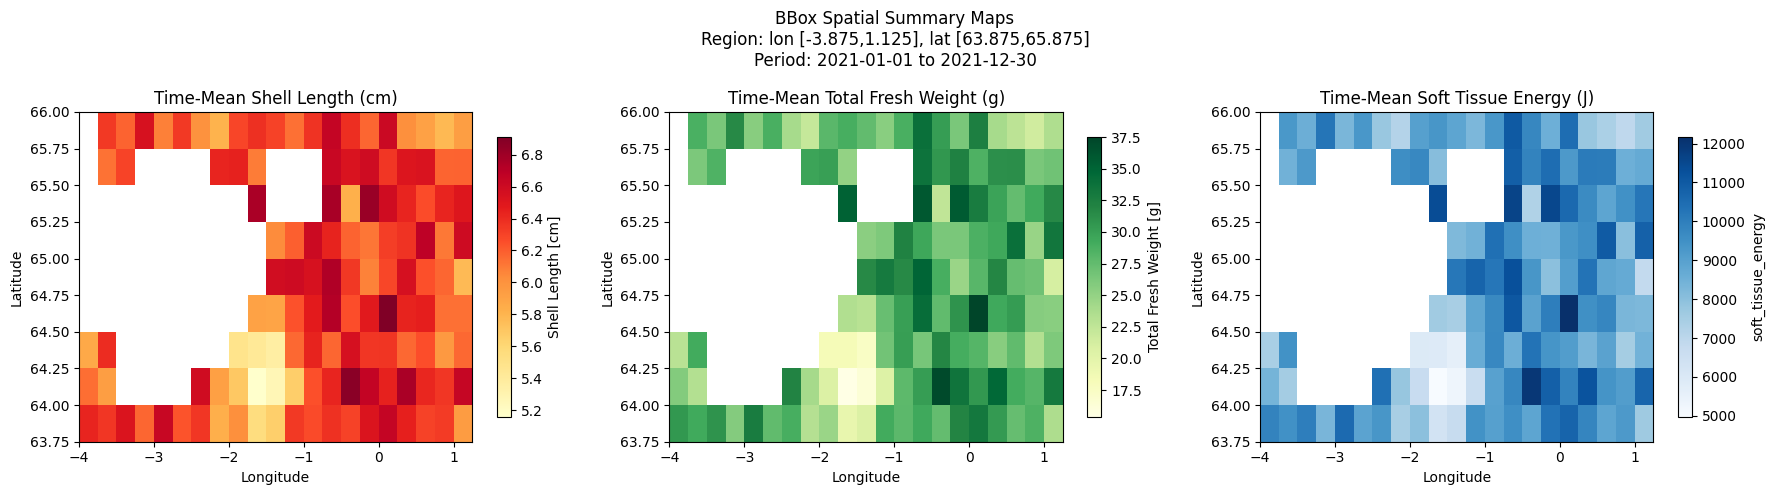

Saved: bbox_spatial_summary.png


In [50]:
# ============================================================
# CELL F: BBOX SPATIAL SUMMARY MAPS (TIME MEAN)
# ============================================================
# Collapses the time dimension by averaging, then plots each
# variable as a 2-D map over the bounding box.
# xarray's .plot() attaches the colorbar automatically.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_specs = [
    ('SL',                'Shell Length (cm)',     'YlOrRd'),
    ('TFW',               'Total Fresh Weight (g)','YlGn'),
    ('soft_tissue_energy','Soft Tissue Energy (J)','Blues'),
]

for ax, (vname, title, cmap) in zip(axes, plot_specs):
    # skipna=True ignores land / missing-data NaNs in the mean
    da_mean = ds_bbox[vname].mean(dim='time', skipna=True)
    da_mean.plot(ax=ax, cmap=cmap, add_colorbar=True,
                cbar_kwargs={'shrink': 0.85})
    ax.set_title(f'Time-Mean {title}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle(
    f'BBox Spatial Summary Maps\n'
    f'Region: lon [{user_bbox[0]},{user_bbox[2]}], lat [{user_bbox[1]},{user_bbox[3]}]\n'
    f'Period: {user_date_start} to {user_date_end}',
    fontsize=12
)
plt.tight_layout()
# plt.savefig('bbox_spatial_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_spatial_summary.png')


## BBox: Area-Averaged Time Series
Shows how the **spatial mean** of SL, TFW, and Soft Tissue Energy evolves over time
across the entire bounding box, with a shaded band showing pixel-to-pixel variability (±1 std).
This answers: *On average, when does the region reach peak growth?*

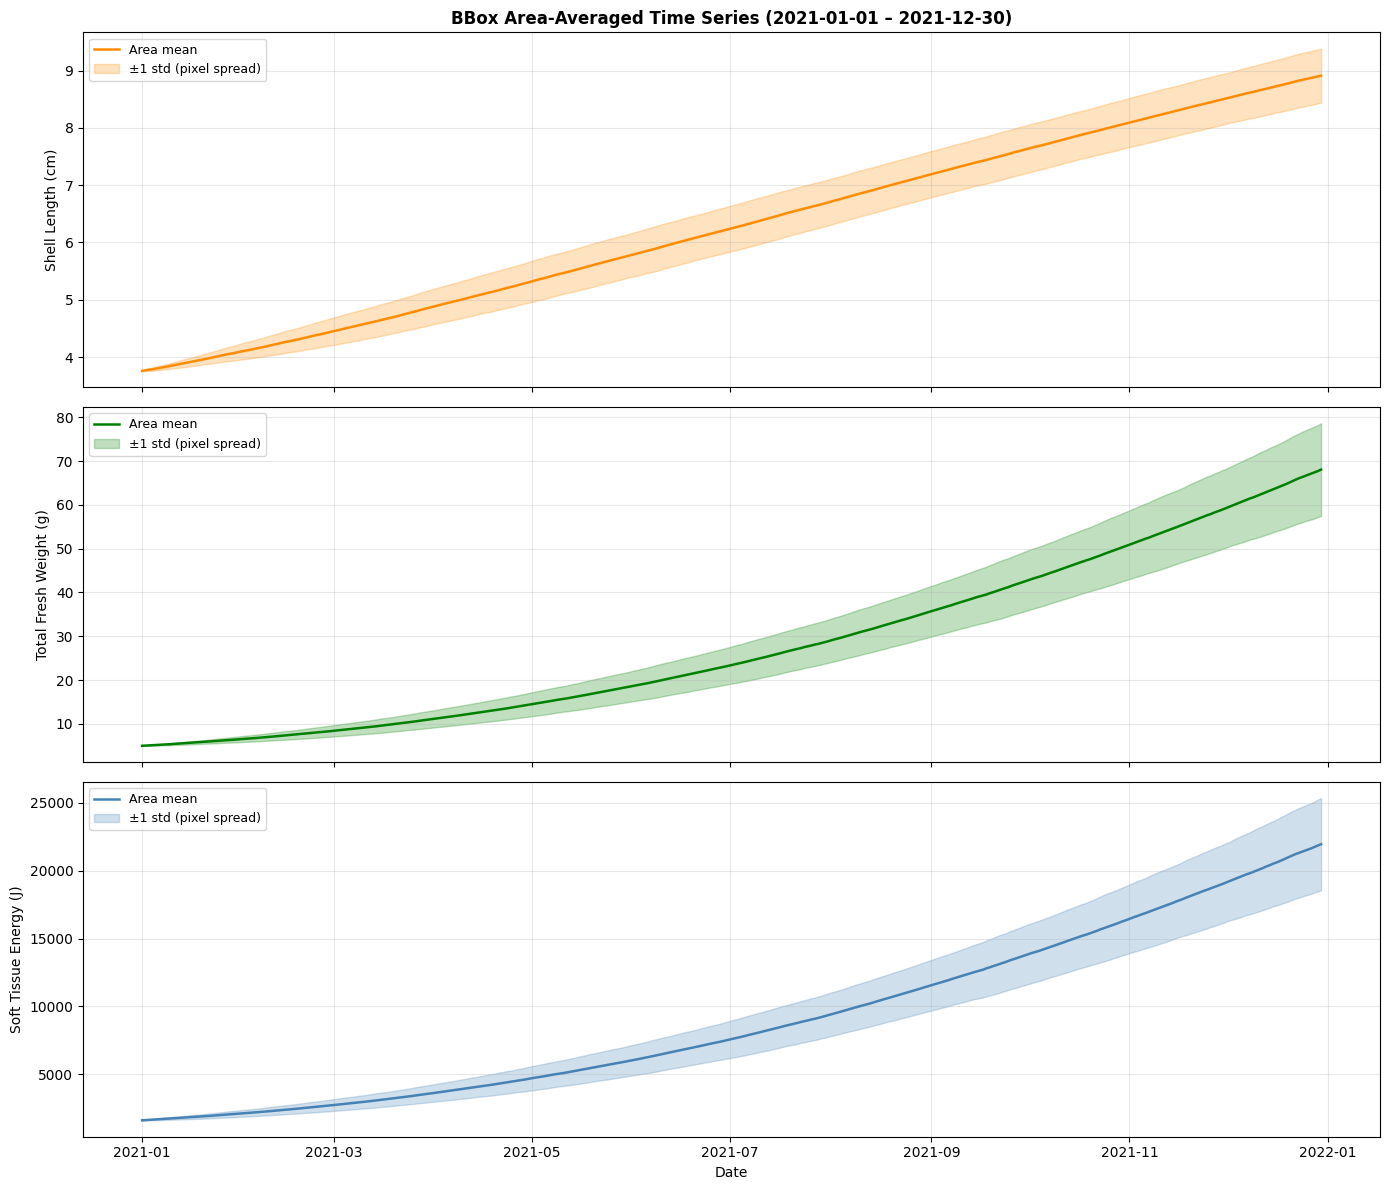

Saved: bbox_area_mean_timeseries.png


In [51]:
# ============================================================
# CELL G: BBOX AREA-AVERAGED TIME SERIES WITH STD BAND
# ============================================================
# Takes the spatial mean across all (lat, lon) pixels for each
# time step (skipna=True to handle land NaNs), plus the spatial
# std as a measure of inter-pixel variability / spatial spread.

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ts_specs = [
    ('SL',                'Shell Length (cm)',     'darkorange'),
    ('TFW',               'Total Fresh Weight (g)','green'),
    ('soft_tissue_energy','Soft Tissue Energy (J)','steelblue'),
]

bbox_times = pd.DatetimeIndex(ds_bbox.time.values)

for ax, (vname, ylabel, color) in zip(axes, ts_specs):
    # Area mean and std across lat and lon at each time step
    area_mean = ds_bbox[vname].mean(dim=['latitude','longitude'], skipna=True).values
    area_std  = ds_bbox[vname].std( dim=['latitude','longitude'], skipna=True).values

    ax.plot(bbox_times, area_mean, color=color, linewidth=1.8, label='Area mean')
    ax.fill_between(bbox_times,
                    area_mean - area_std,
                    area_mean + area_std,
                    alpha=0.25, color=color, label='±1 std (pixel spread)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title(
    f'BBox Area-Averaged Time Series ({user_date_start} – {user_date_end})',
    fontsize=12, fontweight='bold'
)
axes[-1].set_xlabel('Date')
plt.tight_layout()
# plt.savefig('bbox_area_mean_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_area_mean_timeseries.png')


## BBox: Statistical Summary Table
Aggregates all pixels and all time steps within the bounding box into a single summary table,
including min, max, mean, std, and quartiles. Useful for comparing multiple regions side-by-side.

In [60]:
# ============================================================
# CELL H: BBOX STATISTICAL SUMMARY TABLE
# ============================================================
# Flattens each variable across ALL (lat, lon, time) dimensions
# and computes descriptive statistics. NaNs are excluded.

rows = {}
for vname in ['SL', 'TFW', 'soft_tissue_energy']:
    flat = ds_bbox[vname].values.ravel()
    flat = flat[~np.isnan(flat)]
    if len(flat) == 0:
        rows[vname] = {k: np.nan for k in ['min','max','mean','std','p25','p75']}
        continue
    rows[vname] = {
        'min':  round(float(np.min(flat)), 4),
        'max':  round(float(np.max(flat)), 4),
        'mean': round(float(np.mean(flat)), 4),
        'std':  round(float(np.std(flat)), 4),
        'p25':  round(float(np.percentile(flat, 25)), 4),
        'p75':  round(float(np.percentile(flat, 75)), 4),
    }

df_bbox_stats = pd.DataFrame(rows).T
print('=== BBox Statistical Summary (all pixels, all time steps) ===')
print(f'Region : lon [{user_bbox[0]},{user_bbox[2]}], lat [{user_bbox[1]},{user_bbox[3]}]')
print(f'Period : {user_date_start} to {user_date_end}')
print()
print(df_bbox_stats.to_string())


=== BBox Statistical Summary (all pixels, all time steps) ===
Region : lon [-3.875,1.125], lat [63.875,65.875]
Period : 2021-01-01 to 2021-12-30

                          min         max       mean        std        p25         p75
SL                     3.7567      9.9115     6.2693     1.5847     4.8555      7.6121
TFW                    4.8074     92.8785    27.9740    19.3955    10.8428     42.0148
soft_tissue_energy  1277.5424  29727.3555  9054.4160  6256.3257  3528.2946  13600.7749


## BBox: Growth Hotspot Map
Maps the **final Shell Length** at every pixel in the bounding box.
Pixels in the top 10% are highlighted with a red star overlay.
This directly shows *where* within the region oysters grow largest — the prime farming locations.

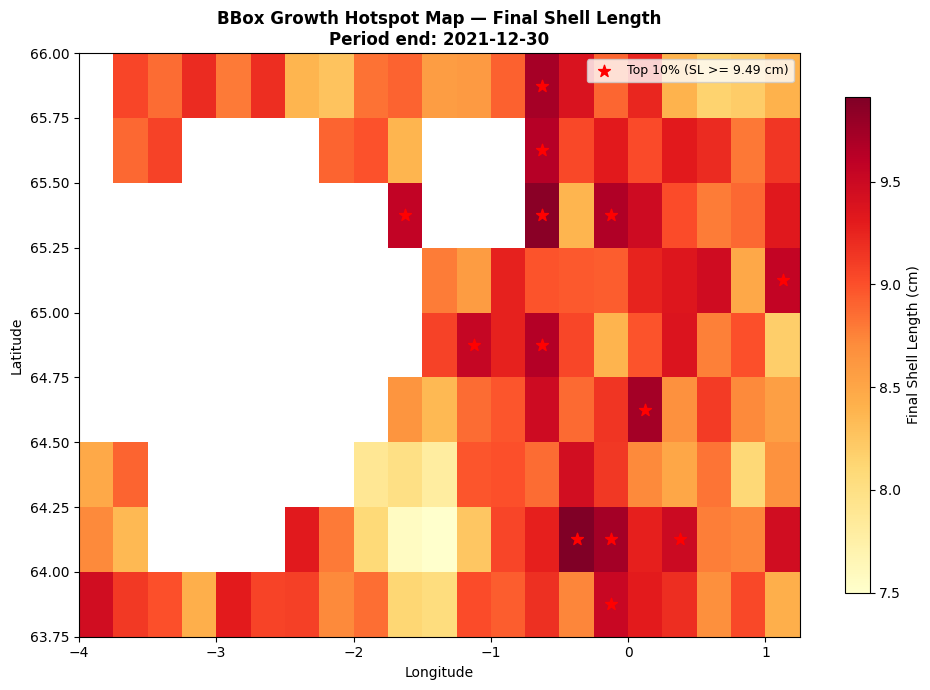

Saved: bbox_hotspot_map.png


In [61]:
# ============================================================
# CELL I: BBOX GROWTH HOTSPOT MAP
# ============================================================
# Extracts SL at the last time step, plots a spatial map,
# and overlays red stars on pixels in the top 10%.

# Final SL = value at the last time step for each pixel
sl_final = ds_bbox['SL'].isel(time=-1).values  # shape (lat, lon)
lats_bbox = ds_bbox.latitude.values
lons_bbox = ds_bbox.longitude.values

# Threshold for top 10% (ignoring NaNs)
sl_flat    = sl_final[~np.isnan(sl_final)]
top10_thresh = np.percentile(sl_flat, 90) if len(sl_flat) > 0 else np.nan

fig, ax = plt.subplots(figsize=(10, 7))

# Plot the final SL map
lon_grid, lat_grid = np.meshgrid(lons_bbox, lats_bbox)
pcm = ax.pcolormesh(lon_grid, lat_grid, sl_final,
                    cmap='YlOrRd', shading='auto')
plt.colorbar(pcm, ax=ax, label='Final Shell Length (cm)', shrink=0.85)

# Overlay red stars on top-10% pixels
if not np.isnan(top10_thresh):
    hot_mask = sl_final >= top10_thresh
    hot_lats_idx, hot_lons_idx = np.where(hot_mask)
    ax.scatter(
        lons_bbox[hot_lons_idx], lats_bbox[hot_lats_idx],
        marker='*', color='red', s=80, zorder=5,
        label=f'Top 10% (SL >= {top10_thresh:.2f} cm)'
    )
    ax.legend(fontsize=9)

ax.set_title(
    f'BBox Growth Hotspot Map — Final Shell Length\n'
    f'Period end: {str(pd.Timestamp(ds_bbox.time.values[-1]).date())}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
# plt.savefig('bbox_hotspot_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_hotspot_map.png')


## BBox: Harvest Readiness Summary
For each pixel, calculates the **fraction of the period** when both SL >= 6 cm AND TFW >= 5 g
are simultaneously satisfied. Plots a spatial map and prints the overall area percentage
that meets harvest thresholds. Gives a spatial picture of which zones are commercially viable.

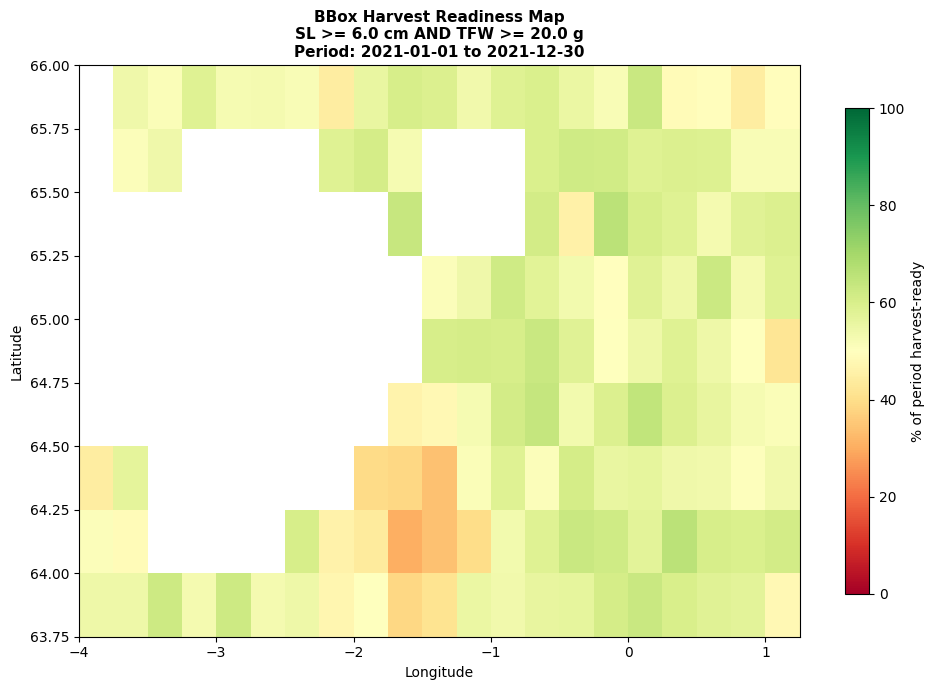

Saved: bbox_harvest_map.png
% of pixels that EVER reach harvest thresholds : 100.0%
Mean harvest-ready fraction across all pixels  : 54.4%


In [62]:
# ============================================================
# CELL J: BBOX HARVEST READINESS MAP
# ============================================================


# xarray loads as (time, latitude, longitude) — axis 0 is time
sl_arr  = ds_bbox['SL'].values   # shape (time, lat, lon)
tfw_arr = ds_bbox['TFW'].values  # shape (time, lat, lon)

# Boolean mask: True where both thresholds met at each time step
both_ready = (sl_arr >= HARVEST_SL_CM) & (tfw_arr >= MARKET_WEIGHT_G)

# Fraction of time steps where both conditions hold — reduce over axis 0 (time)
n_times      = sl_arr.shape[0]                                          # ← was shape[2]
harvest_frac = np.nansum(both_ready.astype(float), axis=0) / n_times   # (lat, lon)
harvest_frac[np.all(np.isnan(sl_arr), axis=0)] = np.nan                # ← was axis=2

# Overall area percentage
valid_pixels   = harvest_frac[~np.isnan(harvest_frac)]
pct_area_ready = 100.0 * np.mean(valid_pixels > 0) if len(valid_pixels) > 0 else 0.0
mean_frac      = 100.0 * np.nanmean(valid_pixels)  if len(valid_pixels) > 0 else 0.0

# Plot — meshgrid matches (lat, lon) order of harvest_frac
fig, ax = plt.subplots(figsize=(10, 7))
lon_grid, lat_grid = np.meshgrid(ds_bbox.longitude.values, ds_bbox.latitude.values)
pcm = ax.pcolormesh(lon_grid, lat_grid, harvest_frac * 100,
                    cmap='RdYlGn', vmin=0, vmax=100, shading='auto')
plt.colorbar(pcm, ax=ax, label='% of period harvest-ready', shrink=0.85)
ax.set_title(
    f'BBox Harvest Readiness Map\n'
    f'SL >= {HARVEST_SL_CM} cm AND TFW >= {MARKET_WEIGHT_G} g\n'
    f'Period: {user_date_start} to {user_date_end}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
# plt.savefig('bbox_harvest_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_harvest_map.png')
print(f'% of pixels that EVER reach harvest thresholds : {pct_area_ready:.1f}%')
print(f'Mean harvest-ready fraction across all pixels  : {mean_frac:.1f}%')


In [63]:
# ============================================================
# CELL JB: BBOX HARVEST READINESS MAP on top of leaflet mapimport folium

# =====================================
import branca
from matplotlib import cm
import folium

# Prepare the raster RGBA image from harvest_frac (values 0..1, NaN = land)
vals_pct = harvest_frac * 100.0  # 0..100, NaNs for land
mask_nan = np.isnan(vals_pct)

# Normalized 0..1 for colormap; clamp
normed = np.zeros_like(vals_pct, dtype=float)
valid_mask = ~mask_nan
if np.any(valid_mask):
    normed[valid_mask] = np.clip(vals_pct[valid_mask], 0.0, 100.0) / 100.0

# Use matplotlib colormap RdYlGn (green = high readiness)
cmap = cm.get_cmap('RdYlGn')
rgba_f = cmap(normed)  # shape (ny, nx, 4), floats 0..1

# Set NaNs to fully transparent
rgba_f[mask_nan, :] = np.array([0.0, 0.0, 0.0, 0.0])

# Convert to uint8 image
rgba_img = (rgba_f * 255).astype(np.uint8)

# Ensure image vertical orientation matches geographic bounds: folium expects image[0] to be top (north).
# If latitude array is descending (north -> south), we should not flip. If it's ascending, flip vertically.
lats = ds_bbox.latitude.values
if lats[0] < lats[-1]:
    rgba_img = np.flipud(rgba_img)

# Compute bounds: [[south, west], [north, east]]
lat_min, lat_max = float(np.min(lats)), float(np.max(lats))
lon_min, lon_max = float(np.min(ds_bbox.longitude.values)), float(np.max(ds_bbox.longitude.values))
bounds = [[lat_min, lon_min], [lat_max, lon_max]]

# Create folium map centered on bbox
center_lat = float(np.nanmean([lat_min, lat_max]))
center_lon = float(np.nanmean([lon_min, lon_max]))
m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles='CartoDB positron')

# Add the image overlay as a toggleable layer
overlay = folium.raster_layers.ImageOverlay(
    image=rgba_img,
    bounds=bounds,
    name='Harvest Readiness (%)',
    opacity=0.75,
    interactive=True,
    cross_origin=False,
    zindex=1,
)
overlay.add_to(m)

# Add a marker popup with summary stats (optional)
summary_html = (
    f"<b>BBox Harvest Readiness</b><br>"
    f"% pixels ever ready : {pct_area_ready:.1f}%<br>"
    f"Mean readiness (% of period) : {mean_frac:.1f}%<br>"
    f"Thresholds: SL >= {HARVEST_SL_CM} cm & TFW >= {MARKET_WEIGHT_G} g<br>"
    f"Period: {user_date_start} to {user_date_end}"
)
folium.Marker(
    location=[center_lat, center_lon],
    icon=folium.Icon(icon='info-sign'),
    popup=folium.Popup(summary_html, max_width=300)
).add_to(m)

# Add colorbar legend using branca
cmap_branca = branca.colormap.LinearColormap(
    colors=['red', 'yellow', 'green'],
    vmin=0, vmax=100,
    caption='% of period harvest-ready'
)
cmap_branca.add_to(m)

# Layer control to toggle the readiness overlay
folium.LayerControl(collapsed=False).add_to(m)

# Save and display path
out_html = 'bbox_harvest_leaflet.html'
# m.save(out_html)
print(f'Saved: {out_html}')

# If in a Jupyter environment, display inline (will be ignored otherwise)
try:
    display(m)
except Exception:
    pass


Saved: bbox_harvest_leaflet.html


/tmp/ipykernel_147570/2756531266.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn')


## BBox: Distribution Violin / Box Plots
Shows the **distribution** of final SL and TFW values across all pixels in the bounding box
as violin plots. The width of each violin indicates how common each value is.
Harvest thresholds are overlaid so you can immediately see what fraction of the pixel
population reached commercial size.

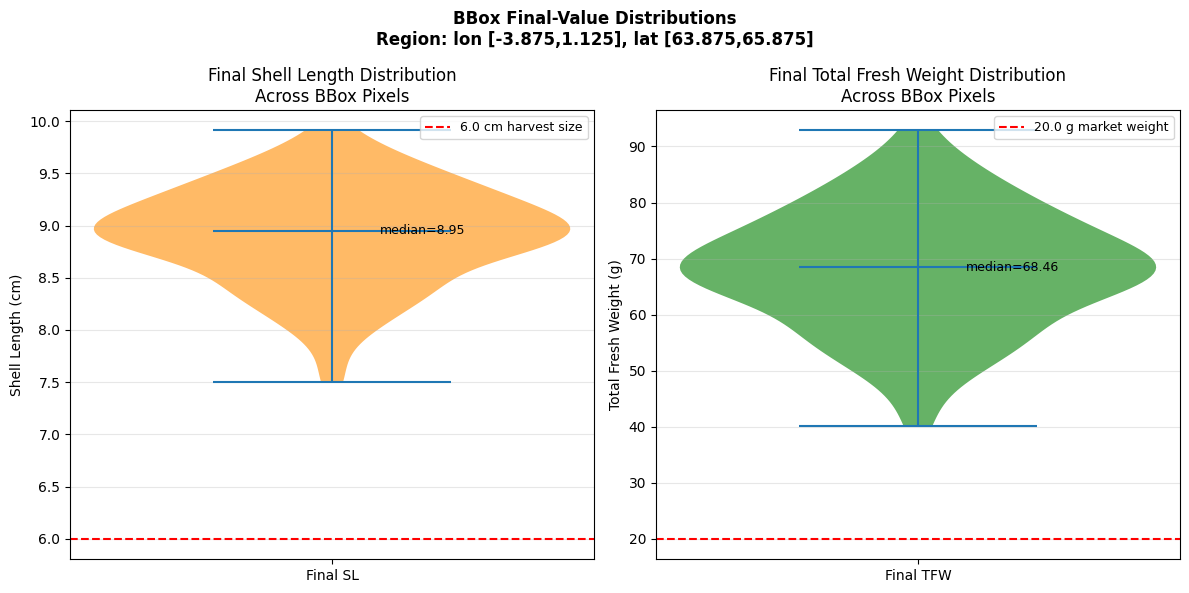

Saved: bbox_distributions.png


In [64]:
# ============================================================
# CELL K: BBOX DISTRIBUTION VIOLIN / BOX PLOTS
# ============================================================
# Collects the final-time-step value of SL and TFW for every
# pixel, then displays as violin plots (distribution shape)
# with median line and harvest threshold annotations.

# Final values across all pixels (last time step)
sl_final_flat  = ds_bbox['SL'].isel(time=-1).values.ravel()
tfw_final_flat = ds_bbox['TFW'].isel(time=-1).values.ravel()

# Remove NaNs (land pixels)
sl_final_flat  = sl_final_flat[~np.isnan(sl_final_flat)]
tfw_final_flat = tfw_final_flat[~np.isnan(tfw_final_flat)]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Panel 1: Shell Length violin ---
ax = axes[0]
if len(sl_final_flat) > 0:
    vp = ax.violinplot(sl_final_flat, positions=[1], showmedians=True)
    for pc in vp['bodies']:
        pc.set_facecolor('darkorange')
        pc.set_alpha(0.6)
    ax.axhline(HARVEST_SL_CM, color='red', linestyle='--', linewidth=1.5,
               label=f'{HARVEST_SL_CM} cm harvest size')
    ax.set_xticks([1])
    ax.set_xticklabels(['Final SL'])
    median_sl = float(np.median(sl_final_flat))
    ax.text(1.05, median_sl, f'median={median_sl:.2f}', va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'No valid SL data', ha='center', transform=ax.transAxes)
ax.set_title('Final Shell Length Distribution\nAcross BBox Pixels')
ax.set_ylabel('Shell Length (cm)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Panel 2: Total Fresh Weight violin ---
ax = axes[1]
if len(tfw_final_flat) > 0:
    vp = ax.violinplot(tfw_final_flat, positions=[1], showmedians=True)
    for pc in vp['bodies']:
        pc.set_facecolor('green')
        pc.set_alpha(0.6)
    ax.axhline(MARKET_WEIGHT_G, color='red', linestyle='--', linewidth=1.5,
               label=f'{MARKET_WEIGHT_G} g market weight')
    ax.set_xticks([1])
    ax.set_xticklabels(['Final TFW'])
    median_tfw = float(np.median(tfw_final_flat))
    ax.text(1.05, median_tfw, f'median={median_tfw:.2f}', va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'No valid TFW data', ha='center', transform=ax.transAxes)
ax.set_title('Final Total Fresh Weight Distribution\nAcross BBox Pixels')
ax.set_ylabel('Total Fresh Weight (g)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'BBox Final-Value Distributions\n'
    f'Region: lon [{user_bbox[0]},{user_bbox[2]}], lat [{user_bbox[1]},{user_bbox[3]}]',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
# plt.savefig('bbox_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bbox_distributions.png')


# Section 3 

In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Find a valid (non-NaN) pixel automatically
#
# WHY NEEDED?
#   Over land or near missing-data edges, the model returns NaN.
#   If you hard-code a lat/lon that falls on land the plots will be empty.
#   This cell scans the TFW variable and finds the first pixel with real data.
#
# WHAT IT SETS:
#   `valid_lat`, `valid_lon` – a guaranteed valid starting point for plotting.
#   These are printed so you can copy them into the point-insight cell below.
#
# FIX: collapse the time dimension FIRST so np.where operates on a 2-D
#   (lat, lon) array and returns a 2-tuple of indices, not a 3-tuple.
# ─────────────────────────────────────────────────────────────────────────────

print('Scanning output for first valid (non-NaN) data pixel...')

# Collapse time → 2-D boolean mask: True where pixel has ≥1 non-NaN step
valid_mask_2d = ~ds_out['C1'].isnull().all(dim='time')   # shape (latitude, longitude)
valid_indices = np.where(valid_mask_2d.values)           # 2-tuple: (lat_idx_arr, lon_idx_arr)

if len(valid_indices[0]) == 0:
    print('❌ ERROR: The entire dataset is NaN.  Check your input data quality.')
    valid_lat, valid_lon = None, None
else:
    first_lat_idx = valid_indices[0][0]   # index along latitude dimension
    first_lon_idx = valid_indices[1][0]   # index along longitude dimension
    valid_lat = float(ds_out.latitude.isel(latitude=first_lat_idx).values)
    valid_lon = float(ds_out.longitude.isel(longitude=first_lon_idx).values)
    print(f'\n✅ First valid pixel found:')
    print(f'   Latitude  : {valid_lat}')
    print(f'   Longitude : {valid_lon}')
    print(f'\nUse these in the point-insight cell below, or pick any blue pixel from the coverage map.')

Scanning output for first valid (non-NaN) data pixel...

✅ First valid pixel found:
   Latitude  : 63.875
   Longitude : -4.875

Use these in the point-insight cell below, or pick any blue pixel from the coverage map.


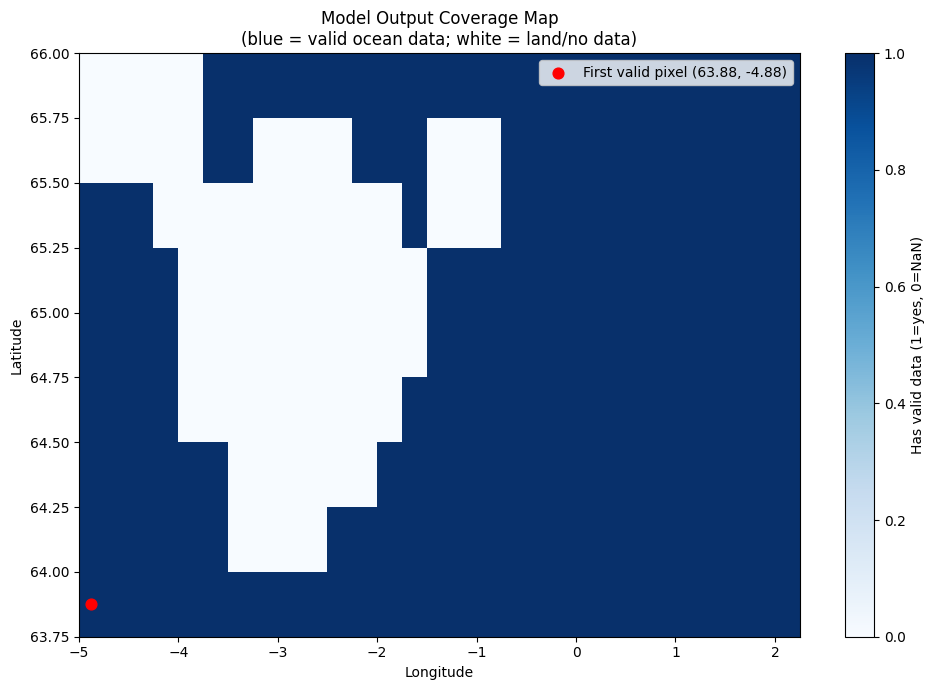

Saved: coverage_map.png


In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Data coverage map
#
# This map shows WHERE the model produced valid results.
#   Blue  = valid data  (ocean pixels with complete input forcing)
#   White = NaN         (land, ice, or pixels with missing input data)
#
# HOW TO READ:
#   Pick a blue pixel's coordinates for the point-insight cell below.
#   Draw a bounding box over a group of blue pixels for the area-insight cell.
# ─────────────────────────────────────────────────────────────────────────────

data_coverage = ~ds_out['C1'].isnull().all(dim='time')

fig, ax = plt.subplots(figsize=(10, 7))
data_coverage.plot(
    ax=ax,
    cmap='Blues',
    cbar_kwargs={'label': 'Has valid data (1=yes, 0=NaN)'}
)
if valid_lat is not None:
    ax.scatter(valid_lon, valid_lat, color='red', s=60, zorder=5, label=f'First valid pixel ({valid_lat:.2f}, {valid_lon:.2f})')
    ax.legend()
ax.set_title('Model Output Coverage Map\n(blue = valid ocean data; white = land/no data)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
# plt.savefig('coverage_map.png', dpi=150)
plt.show()
print('Saved: coverage_map.png')


---
## Single-Point Insight Dashboard

Set `plot_lat` and `plot_lon` to any ocean location within your grid.
The cell below generates a **7-panel dashboard** for that single pixel showing:

1. Soft Tissue Energy trajectory over time
2. Shell Energy trajectory
3. Total Fresh Weight (commercial harvest indicator)
4. Shell Length (size indicator)
5. Driving environmental conditions (Temperature + Salinity)
6. Food availability (Chl, POC, POM, TPM)
7. A printed **summary statistics card** with growth metrics

Copy `valid_lat` / `valid_lon` from the cell above, or choose any coordinate
inside the blue area of the coverage map.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SINGLE-POINT INSIGHT REPORT
  Location : Lat 63.875°  Lon -4.875°
  Period   : 2021-01-01  →  2021-12-31
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Nearest grid pixel: Lat 63.875°  Lon -4.875°

  ┌─────────────────────────────────────────────────────┐
  │  GROWTH SUMMARY STATISTICS                          │
  ├─────────────────────────────────────────────────────┤
  │  Soft Tissue Energy                                 │
  │    Start : 1609.49 J   End : 14722.13 J   Change: +13112.63 J  │
  │    Peak  : 14722.13 J  on 2021-12-31                 │
  ├─────────────────────────────────────────────────────┤
  │  Total Fresh Weight (TFW)                           │
  │    Start : 5.000 g   End : 45.401 g   Change: +40.401 g │
  │    Peak  : 45.401 g  on 2021-12-31                 │
  │    Daily growth rate: 0.1107 g/day               │
  ├─────────────────────────────────────────────────────┤
  │  Shell Length

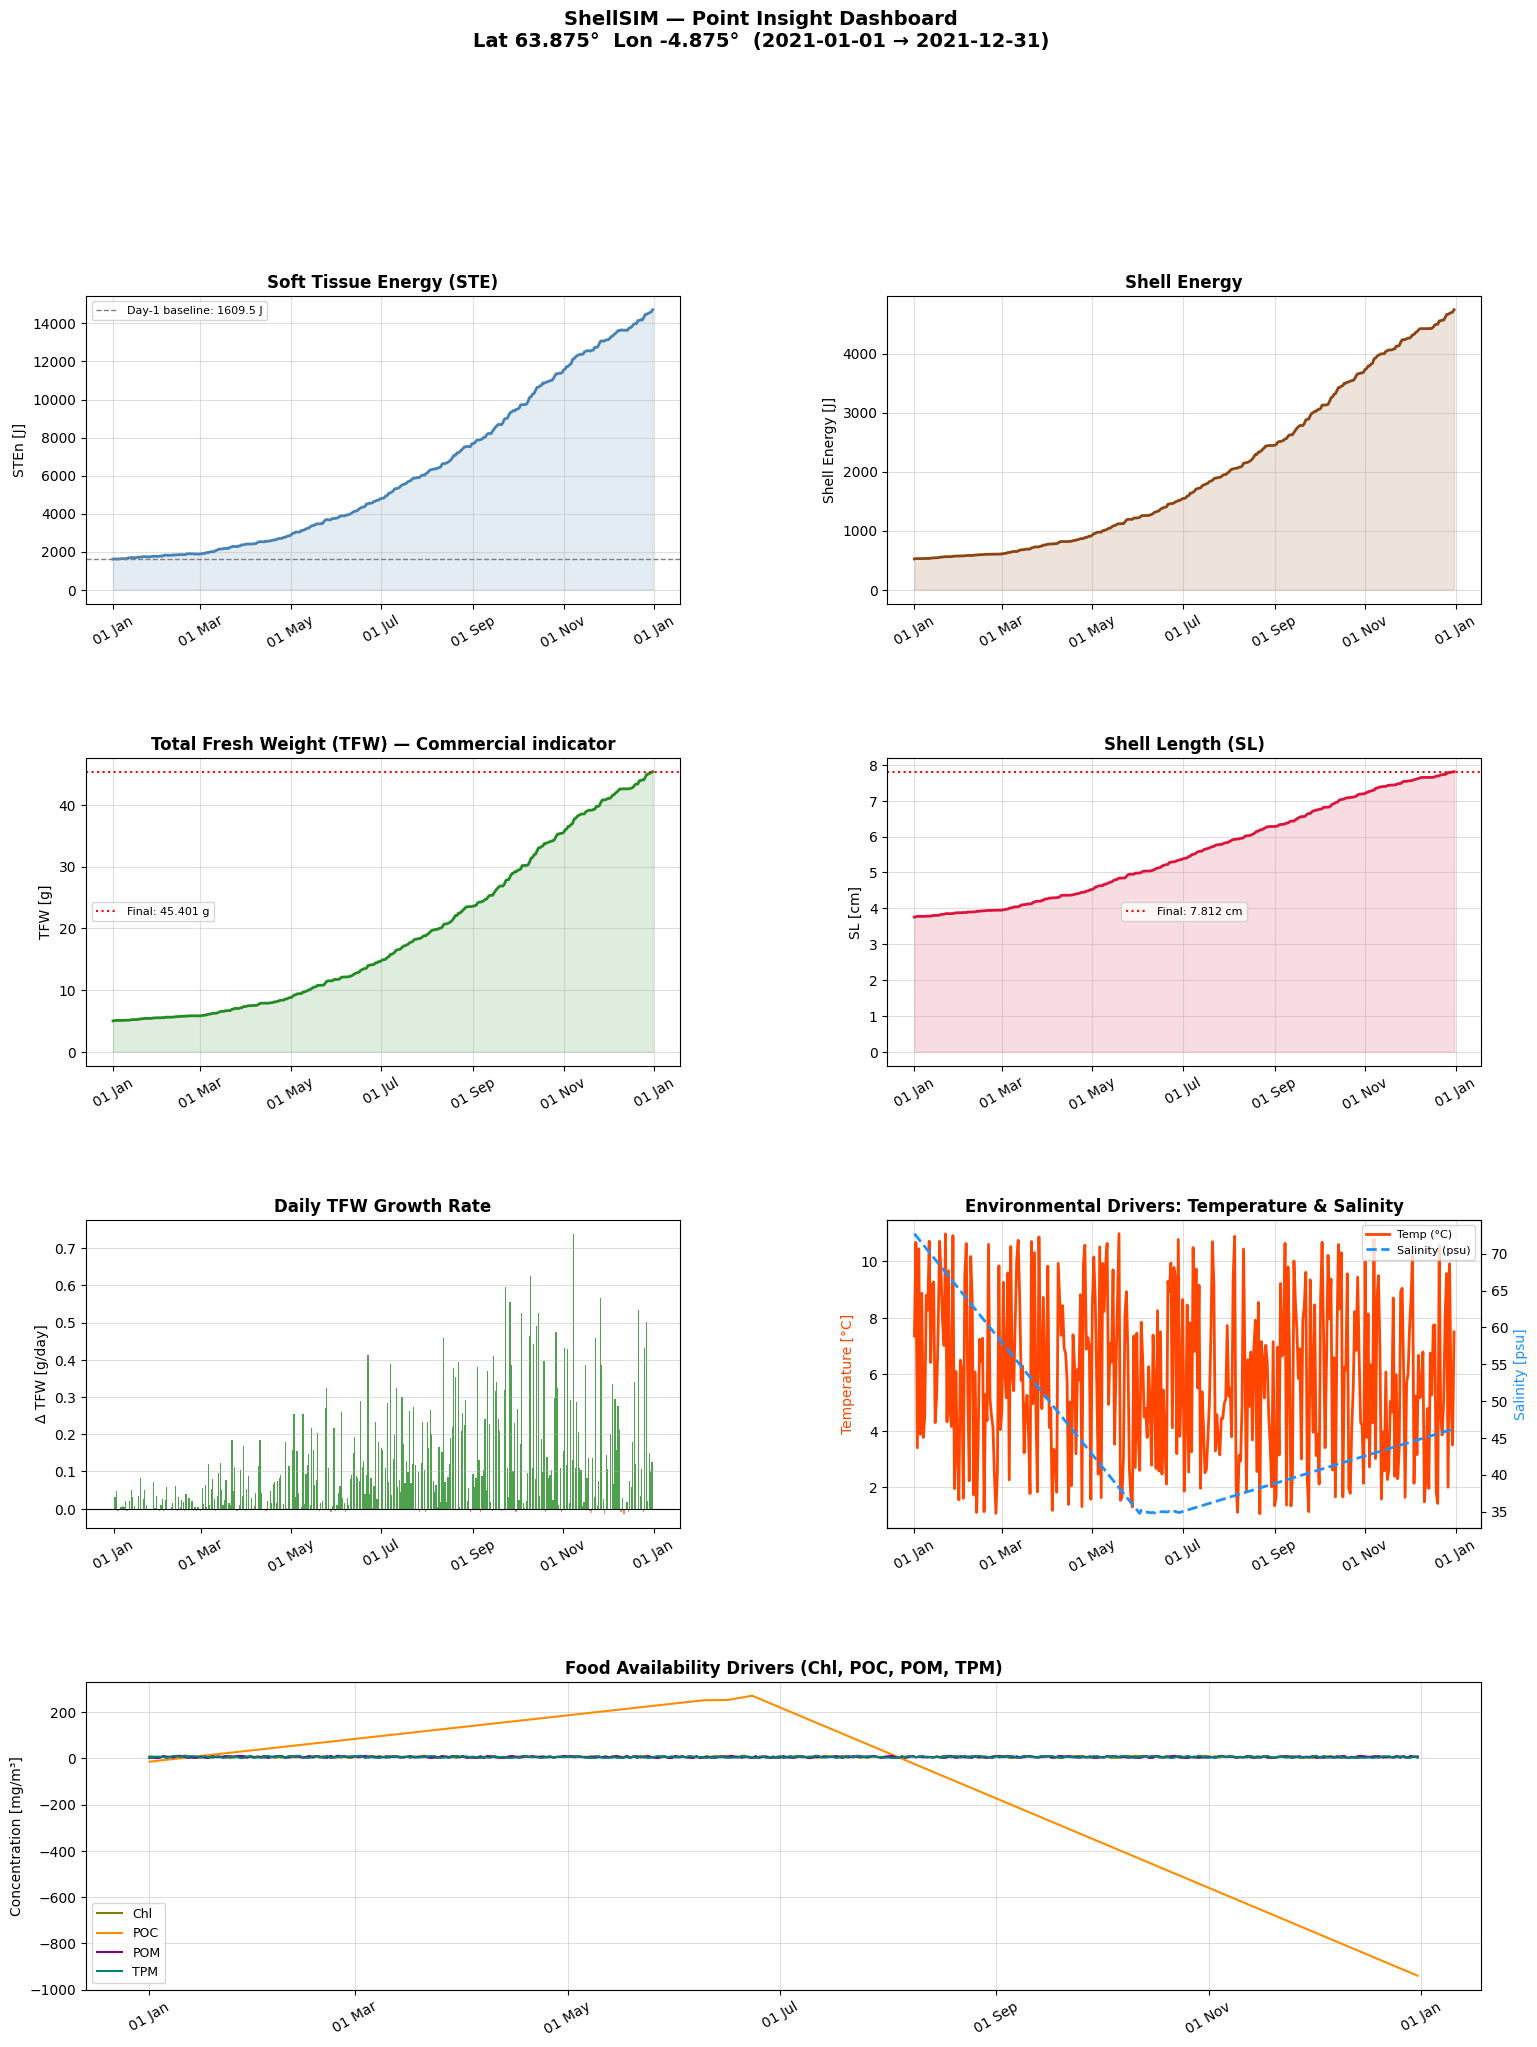


Saved: point_dashboard_63.88_-4.88.png


In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: ENRICHED SINGLE-POINT DASHBOARD
#
# USER INPUTS — change these two values to inspect any grid point:
plot_lat =  63.875   # ← latitude of the point you want to inspect
plot_lon = -4.875    # ← longitude of the point you want to inspect
# TIP: use valid_lat / valid_lon from the cell above if unsure where to start.
# ─────────────────────────────────────────────────────────────────────────────

print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  SINGLE-POINT INSIGHT REPORT')
print(f'  Location : Lat {plot_lat}°  Lon {plot_lon}°')
print(f'  Period   : {str(ds_out.time.values[0])[:10]}  →  {str(ds_out.time.values[-1])[:10]}')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n')

try:
    # Select the nearest grid pixel to the requested lat/lon
    pt = ds_out.sel(latitude=plot_lat, longitude=plot_lon, method='nearest').load()
    actual_lat = float(pt.latitude.values)
    actual_lon = float(pt.longitude.values)
    print(f'  Nearest grid pixel: Lat {actual_lat:.3f}°  Lon {actual_lon:.3f}°\n')

    # Check if this pixel has valid data
    if pt['soft_tissue_energy'].isnull().all():
        print('⚠️  WARNING: All values at this point are NaN.')
        print('   The point may be over land or outside the valid data extent.')
        print('   Use the coverage map above to pick a blue (valid) pixel.')
    else:
        # ─── Derived growth metrics ──────────────────────────────────────────
        # We compute a set of summary statistics that tell an end user how
        # well oysters would grow at this location over the simulated period.
        times   = pd.to_datetime(pt.time.values)
        n_days  = len(times)

        ste_ts   = pt['soft_tissue_energy'].values
        shell_ts = pt['shell_energy'].values

        # ─── Regenerate TFW & SL (NOT saved in the output file) ──────────────
        # TFW (Total Fresh Weight) and SL (Shell Length) are FABM *diagnostics*
        # (Oyster/TFW, Oyster/Shell_Length), not state variables — CELL 40 only
        # wrote the 11 state variables to disk, so they are absent from ds_out.
        # We regenerate them EXACTLY for this single pixel by re-running the
        # model wrapper on the pixel's environmental forcing (cheap: 1 point).
        tfw_ts = np.full(n_days, np.nan)
        sl_ts  = np.full(n_days, np.nan)
        try:
            env_in = ds_daily.sel(latitude=actual_lat, longitude=actual_lon,
                                  method='nearest').load()
            full_out = run_fabm_at_point_full(
                env_in['temperature'].values,
                env_in['salinity'].values,
                env_in['Chl'].values,
                env_in['POC'].values,
                env_in['POM'].values,
                env_in['TPM'].values,
                RUN_LOG_FILENAME,
            )
            tfw_row = VARIABLE_NAMES.index('TFW')
            sl_row  = VARIABLE_NAMES.index('SL')
            m = min(n_days, full_out.shape[1])   # guard against any length mismatch
            tfw_ts[:m] = full_out[tfw_row, :m]
            sl_ts[:m]  = full_out[sl_row,  :m]
        except Exception as _derr:
            print(f'⚠️  Could not regenerate TFW/SL from the model: {_derr}')
            print('   TFW/SL panels will be blank. Ensure ds_daily, '
                  'run_fabm_at_point_full, VARIABLE_NAMES and RUN_LOG_FILENAME '
                  'are still in memory (re-run CELLs 3, 18, 25 and 28).')

        # Growth = final value minus initial value (absolute change over period)
        ste_growth   = ste_ts[-1]   - ste_ts[0]   if not np.isnan(ste_ts[-1])   else np.nan
        shell_growth = shell_ts[-1] - shell_ts[0] if not np.isnan(shell_ts[-1]) else np.nan
        tfw_growth   = tfw_ts[-1]   - tfw_ts[0]   if not np.isnan(tfw_ts[-1])   else np.nan
        sl_growth    = sl_ts[-1]    - sl_ts[0]     if not np.isnan(sl_ts[-1])    else np.nan

        # Daily growth rate = total growth / number of days
        daily_tfw_rate = tfw_growth / n_days if not np.isnan(tfw_growth) else np.nan
        daily_sl_rate  = sl_growth  / n_days if not np.isnan(sl_growth)  else np.nan

        # Peak values
        peak_ste  = np.nanmax(ste_ts)
        peak_sl   = np.nanmax(sl_ts) if not np.all(np.isnan(sl_ts)) else np.nan
        peak_tfw  = np.nanmax(tfw_ts) if not np.all(np.isnan(tfw_ts)) else np.nan

        # Day-of-peak
        day_peak_ste = times[np.nanargmax(ste_ts)].strftime('%Y-%m-%d') if not np.all(np.isnan(ste_ts)) else 'N/A'
        day_peak_tfw = times[np.nanargmax(tfw_ts)].strftime('%Y-%m-%d') if not np.all(np.isnan(tfw_ts)) else 'N/A'

        # ─── Print summary card ───────────────────────────────────────────────
        print('  ┌─────────────────────────────────────────────────────┐')
        print('  │  GROWTH SUMMARY STATISTICS                          │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Soft Tissue Energy                                 │')
        print(f'  │    Start : {ste_ts[0]:.2f} J   End : {ste_ts[-1]:.2f} J   Change: {ste_growth:+.2f} J  │')
        print(f'  │    Peak  : {peak_ste:.2f} J  on {day_peak_ste:<20}       │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Total Fresh Weight (TFW)                           │')
        print(f'  │    Start : {tfw_ts[0]:.3f} g   End : {tfw_ts[-1]:.3f} g   Change: {tfw_growth:+.3f} g │')
        print(f'  │    Peak  : {peak_tfw:.3f} g  on {day_peak_tfw:<20}       │')
        print(f'  │    Daily growth rate: {daily_tfw_rate:.4f} g/day               │')
        print('  ├─────────────────────────────────────────────────────┤')
        print(f'  │  Shell Length (SL)                                  │')
        print(f'  │    Start : {sl_ts[0]:.3f} cm  End : {sl_ts[-1]:.3f} cm  Change: {sl_growth:+.4f} cm│')
        print(f'  │    Peak  : {peak_sl:.3f} cm                                │')
        print(f'  │    Daily growth rate: {daily_sl_rate:.5f} cm/day              │')
        print('  └─────────────────────────────────────────────────────┘')

        # ─── 7-panel dashboard figure ─────────────────────────────────────────
        fig = plt.figure(figsize=(18, 22))
        gs  = GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

        # -- Panel 1: Soft Tissue Energy --
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(times, ste_ts, color='steelblue', lw=2)
        ax1.fill_between(times, ste_ts, alpha=0.15, color='steelblue')
        ax1.axhline(ste_ts[0], color='grey', ls='--', lw=1, label=f'Day-1 baseline: {ste_ts[0]:.1f} J')
        ax1.set_title('Soft Tissue Energy (STE)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('STEn [J]'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.4)

        # -- Panel 2: Shell Energy --
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(times, shell_ts, color='saddlebrown', lw=2)
        ax2.fill_between(times, shell_ts, alpha=0.15, color='saddlebrown')
        ax2.set_title('Shell Energy', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Shell Energy [J]'); ax2.grid(True, alpha=0.4)

        # -- Panel 3: Total Fresh Weight --
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(times, tfw_ts, color='forestgreen', lw=2)
        ax3.fill_between(times, tfw_ts, alpha=0.15, color='forestgreen')
        ax3.axhline(tfw_ts[-1], color='red', ls=':', lw=1.5, label=f'Final: {tfw_ts[-1]:.3f} g')
        ax3.set_title('Total Fresh Weight (TFW) — Commercial indicator', fontsize=12, fontweight='bold')
        ax3.set_ylabel('TFW [g]'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.4)

        # -- Panel 4: Shell Length --
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.plot(times, sl_ts, color='crimson', lw=2)
        ax4.fill_between(times, sl_ts, alpha=0.15, color='crimson')
        ax4.axhline(sl_ts[-1], color='red', ls=':', lw=1.5, label=f'Final: {sl_ts[-1]:.3f} cm')
        ax4.set_title('Shell Length (SL)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('SL [cm]'); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.4)

        # -- Panel 5: Growth rates (daily delta) --
        ax5 = fig.add_subplot(gs[2, 0])
        daily_tfw_delta = np.diff(tfw_ts, prepend=tfw_ts[0])
        colors5 = ['forestgreen' if v >= 0 else 'tomato' for v in daily_tfw_delta]
        ax5.bar(times, daily_tfw_delta, color=colors5, width=0.8, alpha=0.8)
        ax5.axhline(0, color='black', lw=0.8)
        ax5.set_title('Daily TFW Growth Rate', fontsize=12, fontweight='bold')
        ax5.set_ylabel('Δ TFW [g/day]'); ax5.grid(True, axis='y', alpha=0.4)

        # -- Panel 6: Environmental drivers (T + S) --
        ax6 = fig.add_subplot(gs[2, 1])
        if 'temperature' in ds_daily and 'salinity' in ds_daily:
            env_pt = ds_daily.sel(latitude=actual_lat, longitude=actual_lon, method='nearest').load()
            ax6.plot(times, env_pt['temperature'].values, color='orangered', lw=2, label='Temp (°C)')
            ax6b = ax6.twinx()
            ax6b.plot(times, env_pt['salinity'].values, color='dodgerblue', lw=2, ls='--', label='Salinity (psu)')
            ax6b.set_ylabel('Salinity [psu]', color='dodgerblue')
        ax6.set_title('Environmental Drivers: Temperature & Salinity', fontsize=12, fontweight='bold')
        ax6.set_ylabel('Temperature [°C]', color='orangered')
        ax6.grid(True, alpha=0.4)
        lines6a, labs6a = ax6.get_legend_handles_labels()
        lines6b, labs6b = ax6b.get_legend_handles_labels()
        ax6.legend(lines6a + lines6b, labs6a + labs6b, fontsize=8)

        # -- Panel 7: Food availability --
        ax7 = fig.add_subplot(gs[3, :])
        food_colors = {'Chl': 'olive', 'POC': 'darkorange', 'POM': 'purple', 'TPM': 'teal'}
        if 'temperature' in ds_daily:
            env_pt2 = ds_daily.sel(latitude=actual_lat, longitude=actual_lon, method='nearest').load()
            for fvar, fcol in food_colors.items():
                if fvar in env_pt2:
                    ax7.plot(times, env_pt2[fvar].values, lw=1.5, label=fvar, color=fcol)
        ax7.set_title('Food Availability Drivers (Chl, POC, POM, TPM)', fontsize=12, fontweight='bold')
        ax7.set_ylabel('Concentration [mg/m³]'); ax7.legend(fontsize=9); ax7.grid(True, alpha=0.4)

        # Shared x-axis formatting
        for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
            ax.tick_params(axis='x', rotation=30)

        fig.suptitle(
            f'ShellSIM — Point Insight Dashboard\nLat {actual_lat:.3f}°  Lon {actual_lon:.3f}°  '
            f'({str(times[0].date())} → {str(times[-1].date())})',
            fontsize=14, fontweight='bold', y=1.01
        )
        # plt.savefig(f'point_dashboard_{actual_lat:.2f}_{actual_lon:.2f}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'\nSaved: point_dashboard_{actual_lat:.2f}_{actual_lon:.2f}.png')

except Exception as e:
    print(f'\n❌ ERROR loading data for point ({plot_lat}, {plot_lon}): {e}')
    print("   Make sure 'ds_out' is loaded and the coordinate is within the grid.")


---
## Bounding-Box (Area) Insight Dashboard

Users draw a rectangle on a map, set a start/end date, and want to know:
**"How does oyster growth look across the whole area I selected?"**

This cell produces a **multi-panel area report** containing:

| Panel | What it shows | Why it matters |
|---|---|---|
| Spatial mean maps | Average STE, TFW, SL over time | Identify the best-performing zones |
| Area-mean time series | How the 'average oyster' in the box grew | Overall growth trend for the region |
| Spatial variability map | Std-dev of TFW across pixels | Highlights patchy vs. uniform conditions |
| Growth potential map | Final TFW map | Where harvest yield would be highest |
| Histogram | Distribution of final TFW across pixels | Is growth broadly similar or highly skewed? |
| Summary statistics table | Min/max/mean/percentiles per variable | At-a-glance numbers for the drawn area |

**HOW TO USE:**
1. Set `bbox_user` to your drawn bounding box `(min_lon, min_lat, max_lon, max_lat)`.
2. Optionally narrow the time window with `bbox_time_start` / `bbox_time_end`.
3. Run the cell.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AREA INSIGHT REPORT
  Bounding box   : (-4.894118, 63.652092) → (2.264863, 66.124929)
  Grid cells     : 9 lat × 29 lon = 261 pixels
  Time steps     : 365  (2021-01-01 → 2021-12-31)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  AREA STATISTICS (across all pixels, time-mean values)
  ────────────────────────────────────────────────────────────────────────────────
  Soft Tissue Energy (STE)     min=4992.856 J  mean=9043.116 J  max=12222.939 J  p25=8318.141  p75=9890.961
  Total Fresh Weight (TFW)     min=15.440 g  mean=27.947 g  max=37.665 g  p25=25.649  p75=30.635
  Shell Length (SL)            min=5.164 cm  mean=6.271 cm  max=6.920 cm  p25=6.120  p75=6.479
  Final TFW (last day)         min=40.170 g  mean=67.497 g  max=92.873 g  p25=62.011  p75=74.322

  Valid ocean pixels : 192 / 261  (73.6% coverage)

  Area-mean TFW change over period : +62.4969 g  (0.17122 g/day)
  Area-mean SL change over period  : +5.1

/opt/conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


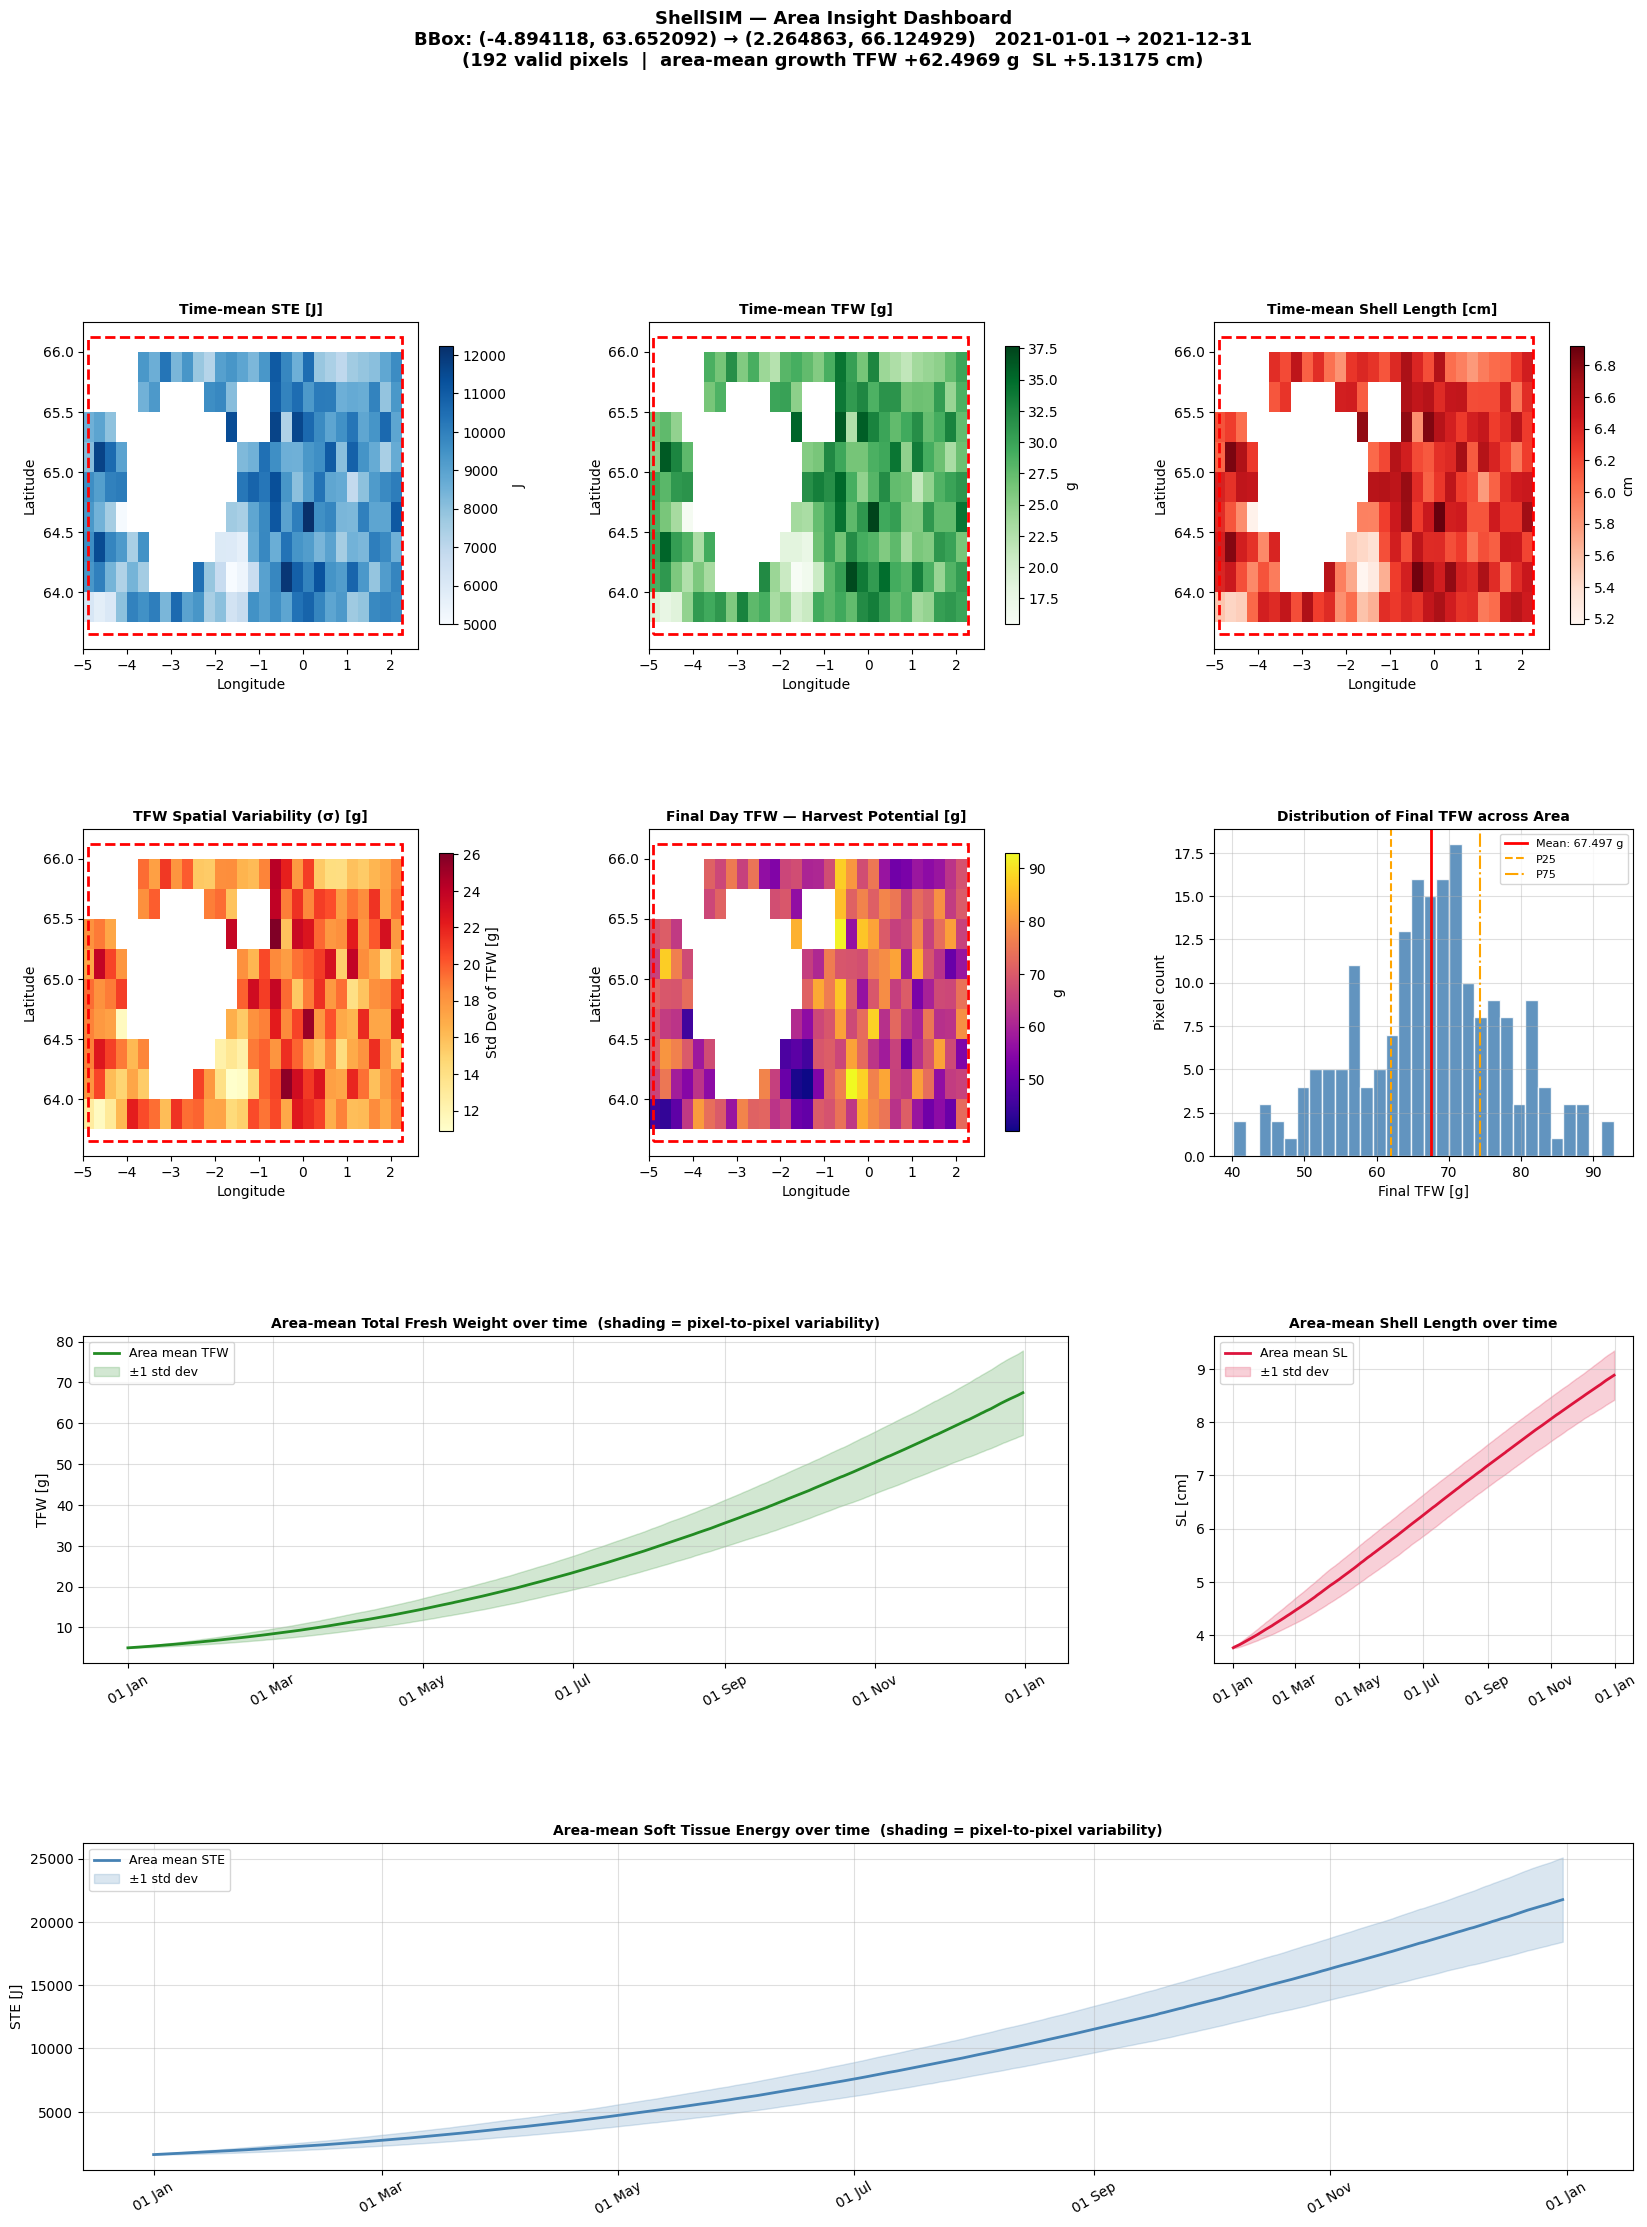


Saved: area_dashboard_bbox.png


In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: BOUNDING-BOX AREA INSIGHT DASHBOARD
#
# Reads from the saved output file (ds_out) — NOT result_dataset.
# Make sure the file-load cell above this has been run so ds_out exists.
#
# USER INPUTS:

bbox_user       = (-4.894118, 63.652092, 2.264863, 66.124929)   # (min_lon, min_lat, max_lon, max_lat)
bbox_time_start = None   # e.g. '2021-06-01' or None to use full time range
bbox_time_end   = None   # e.g. '2021-06-12' or None to use full time range
# ─────────────────────────────────────────────────────────────────────────────

# ── Ensure ds_out is loaded from file with sentinel masking ──────────────────
OUTPUT_FILE = "gridded_oyster_output_ALL_STATES_batched.nc"
ds_out = xr.open_dataset(OUTPUT_FILE, decode_timedelta=False)
ds_out = ds_out.where(ds_out > -90)   # mask ShellSIM -99 sentinel values

min_lon, min_lat, max_lon, max_lat = bbox_user

# ── Clip the output dataset to the drawn bounding box ────────────────────────
ds_bbox = ds_out.sel(
    latitude  = slice(min_lat, max_lat),
    longitude = slice(min_lon, max_lon)
)

if bbox_time_start is not None and bbox_time_end is not None:
    ds_bbox = ds_bbox.sel(time=slice(bbox_time_start, bbox_time_end))

ds_bbox = ds_bbox.compute()

# Use .sizes (not .dims) to avoid FutureWarning
n_lat    = ds_bbox.sizes.get('latitude',  ds_bbox.sizes.get('lat',  0))
n_lon    = ds_bbox.sizes.get('longitude', ds_bbox.sizes.get('lon',  0))
n_t      = ds_bbox.sizes.get('time', 0)
n_pixels = n_lat * n_lon
bbox_times = pd.to_datetime(ds_bbox.time.values)

print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  AREA INSIGHT REPORT')
print(f'  Bounding box   : ({min_lon}, {min_lat}) → ({max_lon}, {max_lat})')
print(f'  Grid cells     : {n_lat} lat × {n_lon} lon = {n_pixels} pixels')
print(f'  Time steps     : {n_t}  ({str(bbox_times[0].date())} → {str(bbox_times[-1].date())})')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n')

# ── Check whether TFW / SL are present in the file ───────────────────────────
has_tfw = 'TFW' in ds_bbox
has_sl  = 'SL'  in ds_bbox
if not has_tfw or not has_sl:
    print('⚠️  TFW and/or SL not found in output file.')
    print('   Re-run the batched model cell with the fixed wrapper (N_OUTPUTS=13).')
    raise RuntimeError('Missing TFW or SL in output file.')

# ── Area-mean time series ─────────────────────────────────────────────────────
area_mean = ds_bbox[['soft_tissue_energy', 'shell_energy', 'TFW', 'SL']].mean(
    dim=['latitude', 'longitude'], skipna=True
)
area_std = ds_bbox[['soft_tissue_energy', 'shell_energy', 'TFW', 'SL']].std(
    dim=['latitude', 'longitude'], skipna=True
)

# ── Spatial maps (time-mean per pixel) ───────────────────────────────────────
spatial_mean_ste  = ds_bbox['soft_tissue_energy'].mean(dim='time', skipna=True)
spatial_mean_tfw  = ds_bbox['TFW'].mean(dim='time', skipna=True)
spatial_mean_sl   = ds_bbox['SL'].mean(dim='time',  skipna=True)
spatial_std_tfw   = ds_bbox['TFW'].std(dim='time',  skipna=True)
spatial_final_tfw = ds_bbox['TFW'].isel(time=-1)

# ── Summary statistics table ──────────────────────────────────────────────────
def area_stats(da, name, units):
    vals = da.values.flatten()
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return f'  {name:<28} all NaN'
    return (f'  {name:<28} min={vals.min():.3f} {units}  '
            f'mean={vals.mean():.3f} {units}  '
            f'max={vals.max():.3f} {units}  '
            f'p25={np.percentile(vals, 25):.3f}  '
            f'p75={np.percentile(vals, 75):.3f}')

print('  AREA STATISTICS (across all pixels, time-mean values)')
print('  ' + '─' * 80)
print(area_stats(spatial_mean_ste,  'Soft Tissue Energy (STE)', 'J'))
print(area_stats(spatial_mean_tfw,  'Total Fresh Weight (TFW)', 'g'))
print(area_stats(spatial_mean_sl,   'Shell Length (SL)',        'cm'))
print(area_stats(spatial_final_tfw, 'Final TFW (last day)',     'g'))

valid_pixel_count = int((~np.isnan(spatial_final_tfw.values)).sum())
print(f'\n  Valid ocean pixels : {valid_pixel_count} / {n_pixels}  ({100*valid_pixel_count/max(n_pixels,1):.1f}% coverage)')

tfw_vals = area_mean['TFW'].values
sl_vals  = area_mean['SL'].values
area_tfw_growth = float(tfw_vals[-1] - tfw_vals[0]) if not np.isnan(tfw_vals[-1]) else np.nan
area_sl_growth  = float(sl_vals[-1]  - sl_vals[0])  if not np.isnan(sl_vals[-1])  else np.nan
print(f'\n  Area-mean TFW change over period : {area_tfw_growth:+.4f} g  ({area_tfw_growth/n_t:.5f} g/day)')
print(f'  Area-mean SL change over period  : {area_sl_growth:+.5f} cm ({area_sl_growth/n_t:.6f} cm/day)')
print('\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

# ═══════════════════════════════════════════════════════════════════════════════
# MULTI-PANEL AREA DASHBOARD FIGURE
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 24))
gs  = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

def plot_map(ax, da, title, cmap, units, cbar_label=None):
    try:
        lat_dim = 'latitude' if 'latitude' in da.dims else 'lat'
        lon_dim = 'longitude' if 'longitude' in da.dims else 'lon'
        im = ax.pcolormesh(
            da[lon_dim].values, da[lat_dim].values, da.values,
            cmap=cmap, shading='auto'
        )
        plt.colorbar(im, ax=ax, shrink=0.85, label=cbar_label or units)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        rect = mpatches.Rectangle(
            (min_lon, min_lat), max_lon - min_lon, max_lat - min_lat,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)

# -- ROW 1: Spatial mean maps --
plot_map(fig.add_subplot(gs[0, 0]), spatial_mean_ste, 'Time-mean STE [J]',          'Blues',  'J')
plot_map(fig.add_subplot(gs[0, 1]), spatial_mean_tfw, 'Time-mean TFW [g]',          'Greens', 'g')
plot_map(fig.add_subplot(gs[0, 2]), spatial_mean_sl,  'Time-mean Shell Length [cm]', 'Reds',  'cm')

# -- ROW 2: Variability + final harvest potential --
plot_map(fig.add_subplot(gs[1, 0]), spatial_std_tfw,   'TFW Spatial Variability (σ) [g]',       'YlOrRd', 'g',
         cbar_label='Std Dev of TFW [g]')
plot_map(fig.add_subplot(gs[1, 1]), spatial_final_tfw, 'Final Day TFW — Harvest Potential [g]', 'plasma', 'g')

ax_hist = fig.add_subplot(gs[1, 2])
final_tfw_flat = spatial_final_tfw.values.flatten()
final_tfw_flat = final_tfw_flat[~np.isnan(final_tfw_flat)]
if len(final_tfw_flat) > 0:
    ax_hist.hist(final_tfw_flat, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax_hist.axvline(np.mean(final_tfw_flat),          color='red',    lw=2,   label=f'Mean: {np.mean(final_tfw_flat):.3f} g')
    ax_hist.axvline(np.percentile(final_tfw_flat, 25), color='orange', lw=1.5, ls='--', label='P25')
    ax_hist.axvline(np.percentile(final_tfw_flat, 75), color='orange', lw=1.5, ls='-.', label='P75')
    ax_hist.set_xlabel('Final TFW [g]')
    ax_hist.set_ylabel('Pixel count')
    ax_hist.set_title('Distribution of Final TFW across Area', fontsize=10, fontweight='bold')
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.4)
else:
    ax_hist.text(0.5, 0.5, 'No valid TFW data in bbox', ha='center', va='center',
                 transform=ax_hist.transAxes)

# -- ROW 3: Area-mean time series --
ax_ts1 = fig.add_subplot(gs[2, :2])
ax_ts1.plot(bbox_times, area_mean['TFW'].values, color='forestgreen', lw=2, label='Area mean TFW')
ax_ts1.fill_between(
    bbox_times,
    area_mean['TFW'].values - area_std['TFW'].values,
    area_mean['TFW'].values + area_std['TFW'].values,
    alpha=0.2, color='forestgreen', label='±1 std dev'
)
ax_ts1.set_title('Area-mean Total Fresh Weight over time  (shading = pixel-to-pixel variability)',
                 fontsize=10, fontweight='bold')
ax_ts1.set_ylabel('TFW [g]')
ax_ts1.legend(fontsize=9)
ax_ts1.grid(True, alpha=0.4)

ax_ts2 = fig.add_subplot(gs[2, 2])
ax_ts2.plot(bbox_times, area_mean['SL'].values, color='crimson', lw=2, label='Area mean SL')
ax_ts2.fill_between(
    bbox_times,
    area_mean['SL'].values - area_std['SL'].values,
    area_mean['SL'].values + area_std['SL'].values,
    alpha=0.2, color='crimson', label='±1 std dev'
)
ax_ts2.set_title('Area-mean Shell Length over time', fontsize=10, fontweight='bold')
ax_ts2.set_ylabel('SL [cm]')
ax_ts2.legend(fontsize=9)
ax_ts2.grid(True, alpha=0.4)

# -- ROW 4: STE area-mean time series --
ax_ste = fig.add_subplot(gs[3, :])
ax_ste.plot(bbox_times, area_mean['soft_tissue_energy'].values, color='steelblue', lw=2, label='Area mean STE')
ax_ste.fill_between(
    bbox_times,
    area_mean['soft_tissue_energy'].values - area_std['soft_tissue_energy'].values,
    area_mean['soft_tissue_energy'].values + area_std['soft_tissue_energy'].values,
    alpha=0.2, color='steelblue', label='±1 std dev'
)
ax_ste.set_title('Area-mean Soft Tissue Energy over time  (shading = pixel-to-pixel variability)',
                 fontsize=10, fontweight='bold')
ax_ste.set_ylabel('STE [J]')
ax_ste.legend(fontsize=9)
ax_ste.grid(True, alpha=0.4)

for ax in [ax_ts1, ax_ts2, ax_ste]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=30)

tfw_growth_str = f'{area_tfw_growth:+.4f} g' if not np.isnan(area_tfw_growth) else 'N/A'
sl_growth_str  = f'{area_sl_growth:+.5f} cm' if not np.isnan(area_sl_growth)  else 'N/A'

fig.suptitle(
    f'ShellSIM — Area Insight Dashboard\n'
    f'BBox: ({min_lon}, {min_lat}) → ({max_lon}, {max_lat})   '
    f'{str(bbox_times[0].date())} → {str(bbox_times[-1].date())}\n'
    f'({valid_pixel_count} valid pixels  |  area-mean growth TFW {tfw_growth_str}  SL {sl_growth_str})',
    fontsize=13, fontweight='bold', y=1.01
)

plt.show()
print('\nSaved: area_dashboard_bbox.png')

In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Load a previously saved output file for standalone exploration
#
# Change output_file_path to point at whatever .nc file you want to inspect.
# ─────────────────────────────────────────────────────────────────────────────

output_file_path = '/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/gridded_oyster_output_ALL_STATES_batched.nc'

if os.path.exists(output_file_path):
    ds_loaded = load_nc_file(output_file_path, 'SL')
    print(ds_loaded)
else:
    print(f'File not found: {output_file_path}')
    print('Run Methods 1 or 2 above to generate the output first.')

Successfully loaded: SL
🗺️ Geographic Coverage:
  BBOX (xMin, yMin, xMax, yMax)
  BBOX (-4.88, 63.88, 2.12, 65.88)
  Lat Range: 63.88° to 65.88° (2.00°)
  Lon Range: -4.88° to 2.12° (7.00°)
  Approximate Area: 73,497 km²
---------------------------------------------------

<xarray.Dataset> Size: 5MB
Dimensions:             (time: 365, latitude: 9, longitude: 29)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-31
  * latitude            (latitude) float32 36B 63.88 64.12 64.38 ... 65.62 65.88
  * longitude           (longitude) float32 116B -4.875 -4.625 ... 1.875 2.125
Data variables: (12/13)
    soft_tissue_energy  (time, latitude, longitude) float32 381kB ...
    shell_energy        (time, latitude, longitude) float32 381kB ...
    aging               (time, latitude, longitude) float32 381kB ...
    C1                  (time, latitude, longitude) float32 381kB ...
    C2                  (time, latitude, longitude) float32 381kB ...
    C3      